# Cognitive & Behavioral Predictors of Student Outcomes

**Group Members:** Mohammad Zoraiz (mz248), Rithik Duvva (rrd18), Kartikeye Gupta (kg330), Ratish Korrapati (rsk49), Enoch Li (yel6)  
**Course:** CS216 Everything Data (Spring 2026)  
**Date:** Feb 19, 2026  
**Repo:** [CampusSignals](https://github.com/zoraizmohammad/CampusSignals)  

## AI Disclosure
Artificial Intelligence Tools: ChatGPT (OpenAI, ChatGPT Edu via Duke University, accessed Jan–Feb 2026)  
- Conceptualization: refined and narrowed research questions.  
- Information collection: located documented, non-synthetic datasets and documentation.  
- Methodology support: suggested mediation-style analysis + supervised ML with ablation testing.  
- Writing/review/editing: improved structure and clarity.

---

## Research Questions
1. How do screen-use patterns (including type), sleep characteristics, and behavioral indicators relate to academic outcomes (grades/GPA proxies)?
2. To what extent do sleep characteristics mediate the relationship between screen use and academic outcomes?
3. Can we predict student outcomes from behavioral and sleep-related features, and which feature groups contribute most?

---

## Modules (mapped to this notebook)
- **Visualization (Module 3):** distributions, relationships, stratified plots, model diagnostics.
- **Data Wrangling (Module 4):** missingness handling, encoding, feature engineering.
- **Statistical Inference (Module 7):** multivariable regression + mediation-style inference with uncertainty.
- **Prediction & Supervised ML (Module 8):** cross-validation, ablations, and interpretability/feature importance.

---

## Notebook Output
This notebook runs the same analysis workflow independently on:
- **Dataset A:** `datasets/mendeley/repositorio.xlsx` (adolescents; screen use, sleep, daytime sleepiness, grades)
- **Dataset B:** `datasets/student-life/` (college students; passive sensing + sleep/stress + academic performance)

Then it compares results across cohorts (directionality + predictive performance).

---

## Plan of Attack (sections)
- Dataset A: ingestion -> schema validation -> feature engineering -> EDA -> mediation -> prediction -> ablations
- Dataset B: ingestion -> cohort outcome assembly -> feature engineering (including keyword-based app categories) -> EDA -> mediation -> prediction -> ablations
- Cross-cohort comparison, robustness, and final reproducibility cleanup


## Dataset A (Adolescents)

### A.1 Ingestion & Schema Validation
- Read `datasets/mendeley/repositorio.xlsx`
- Identify columns for screen-use (weekday/weekend, before bedtime), sleep metrics, daytime sleepiness/PDSS, and grades/GPA

### A.2 Wrangling & Feature Engineering
- Clean missingness
- Engineer screen-use features + sleep features
- Create outcome target: averaged GPA proxy = mean(`DI1 lengua`, `DJ1 matematica`)

### A.3 EDA & Visualization
- Distributions, relationships, stratified comparisons

### A.4 Inference / Mediation-Style Workflow
- screen -> sleep -> academic outcome

### A.5 Prediction & Ablations (RQ3)
- Cross-validation prediction with feature-group ablations

---

## Dataset B (College Students)

### B.1 Ingestion (cohort outcome + sleepiness inputs)
- Load `datasets/student-life/dataset/education/grades.csv`
- Load sleepiness survey inputs (e.g., `datasets/student-life/dataset/survey/psqi.csv`)
- Load EMA “Sleep” JSONs (response folder)

### B.2 Feature Engineering
- Passive sensing aggregation into user-level features
- Keyword-based app-to-screen-category mapping (keyword rules defined in-notebook)

### B.3 EDA & Visualization
- Sanity checks and exploratory relationships

### B.4 Inference / Mediation-Style Workflow
- screen -> sleep -> academic outcome

### B.5 Prediction & Ablations (RQ3)
- Cross-validation prediction with feature-group ablations

---

## Cross-Cohort Comparison
- Compare effect directions and predictive performance between Dataset A and B
- Robustness checks + final limitations


# Reproducibility

Set a single global seed **before** any stochastic steps (bootstrap, CV shuffles, permutation tests, `ElasticNetCV`, etc.).

**How to reproduce:** select a Python kernel with dependencies from `requirements.txt` (and `statsmodels` if you use the full mediation path), then **Run All** from the top.

Individual sections also set `SEED` / `random_state` where needed; the next cell defines the notebook-wide default.


In [ ]:
import os

# Notebook-wide default (downstream cells often do `SEED = 42` — keep them aligned here)
RANDOM_SEED = 42
os.environ.setdefault("PYTHONHASHSEED", str(RANDOM_SEED))

import numpy as np

np.random.seed(RANDOM_SEED)

try:
    import random

    random.seed(RANDOM_SEED)
except Exception:
    pass

SEED = RANDOM_SEED
print(f"Reproducibility: RANDOM_SEED={RANDOM_SEED} (numpy + Python random; sklearn uses random_state where passed)")


In [23]:
import re
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd


def _colref_to_col_index(cell_ref: str) -> int:
    """Convert Excel cell ref like 'A1' or 'BC12' to 0-based column index."""
    letters = re.match(r"^[A-Z]+", cell_ref.upper()).group(0)
    idx = 0
    for ch in letters:
        idx = idx * 26 + (ord(ch) - ord('A') + 1)
    return idx - 1


def read_xlsx_first_sheet(xlsx_path: str | Path) -> pd.DataFrame:
    """Read the first sheet from an .xlsx using only ZIP/XML parsing.

    This avoids needing `openpyxl`/`xlrd` in the runtime.
    """
    xlsx_path = Path(xlsx_path)
    with zipfile.ZipFile(xlsx_path, 'r') as zf:
        # Shared strings are used for most cell values.
        shared_strings = {}
        if 'xl/sharedStrings.xml' in zf.namelist():
            shared_xml = zf.read('xl/sharedStrings.xml')
            shared_root = ET.fromstring(shared_xml)
            ns_ss = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
            for idx, si in enumerate(shared_root.findall('.//w:si', ns_ss)):
                parts = []
                for t in si.findall('.//w:t', ns_ss):
                    if t.text:
                        parts.append(t.text)
                shared_strings[idx] = ''.join(parts)

        # Find sheet target (sheet xml file) for the first sheet.
        workbook_xml = zf.read('xl/workbook.xml')
        workbook_root = ET.fromstring(workbook_xml)
        ns_wb = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

        sheets = []
        for sheet in workbook_root.findall('.//w:sheets/w:sheet', ns_wb):
            name = sheet.attrib.get('name')
            rid = sheet.attrib.get('{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id')
            sheets.append((name, rid))
        if not sheets:
            raise ValueError('No sheets found in workbook.xml')

        first_name, first_rid = sheets[0]

        rels_xml = zf.read('xl/_rels/workbook.xml.rels')
        rels_root = ET.fromstring(rels_xml)
        ns_rel = {'r': 'http://schemas.openxmlformats.org/package/2006/relationships'}
        relmap = {}
        for rel in rels_root.findall('.//r:Relationship', ns_rel):
            rid = rel.attrib.get('Id')
            target = rel.attrib.get('Target')
            relmap[rid] = target

        if first_rid not in relmap:
            raise KeyError(f'Could not resolve relationship id {first_rid}')

        target = relmap[first_rid]
        # Target should look like 'worksheets/sheet1.xml'
        if target.startswith('worksheets/'):
            sheet_xml_path = 'xl/' + target
        else:
            # Sometimes it's already fully qualified under xl/
            sheet_xml_path = target
            if not sheet_xml_path.startswith('xl/'):
                sheet_xml_path = 'xl/' + sheet_xml_path

        sheet_xml_bytes = zf.read(sheet_xml_path)
        sheet_root = ET.fromstring(sheet_xml_bytes)
        ns_sheet = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

        rows = sheet_root.findall('.//w:sheetData/w:row', ns_sheet)
        if not rows:
            raise ValueError('No rows found in sheetData')

        # Header row assumed to be first row.
        header_row = rows[0]
        header_cells = header_row.findall('w:c', ns_sheet)
        if not header_cells:
            raise ValueError('No header cells in first row')

        col_indices = []
        for c in header_cells:
            ref = c.attrib.get('r')
            if not ref:
                continue
            col_indices.append(_colref_to_col_index(ref))
        max_col = max(col_indices) + 1

        headers = [''] * max_col
        for c in header_cells:
            cell_ref = c.attrib.get('r', '')
            col_i = _colref_to_col_index(cell_ref)
            t = c.attrib.get('t')
            v = c.find('w:v', ns_sheet)
            if v is None or v.text is None:
                val = ''
            else:
                if t == 's':
                    val = shared_strings.get(int(v.text), '')
                else:
                    val = v.text
            headers[col_i] = (val or '').strip()

        def cell_value(c):
            t = c.attrib.get('t')
            v = c.find('w:v', ns_sheet)
            if v is None or v.text is None:
                return ''
            if t == 's':
                return shared_strings.get(int(v.text), '')
            return v.text

        data = []
        for row in rows[1:]:
            row_vals = [''] * max_col
            for c in row.findall('w:c', ns_sheet):
                ref = c.attrib.get('r')
                if not ref:
                    continue
                col_i = _colref_to_col_index(ref)
                row_vals[col_i] = cell_value(c)
            # Keep rows even if entirely empty; we’ll drop later.
            data.append(row_vals)

        df = pd.DataFrame(data, columns=headers)

        # Drop fully-empty columns/rows.
        df = df.replace(r'^\s*$', np.nan, regex=True)
        df = df.dropna(axis=1, how='all')
        df = df.dropna(axis=0, how='all')

        # Strip column names
        df.columns = [str(c).strip() for c in df.columns]

        print(f"Loaded sheet '{first_name}' with shape={df.shape}")
        return df


# -----------------------
# Dataset A ingestion
# -----------------------

a_path = Path('datasets/mendeley/repositorio.xlsx')
assert a_path.exists(), f"Missing {a_path}"

# Load raw spreadsheet (prefer cached CSV if present for speed)
cache_csv = Path('datasets/mendeley/repositorio.csv')
if cache_csv.exists():
    print(f"Loading cached Dataset A CSV from {cache_csv}")
    A_raw = pd.read_csv(cache_csv)
else:
    print("Loading Dataset A from XLSX (ZIP/XML parsing)")
    A_raw = read_xlsx_first_sheet(a_path)

# Quick schema validation + variable-group mapping
cols = set(map(str, A_raw.columns))

# Outcomes (per plan: lingua/matematica -> averaged GPA proxy)
outcome_cols = [c for c in ['lengua', 'matematica'] if c in cols]

# Daytime sleepiness / PDSS proxy
pdss_cols = [c for c in cols if c.lower().strip() == 'somno01pdss' or 'pdss' in c.lower()]

# Screen-use related columns (heuristics based on Spanish question/variable names)
screen_cols = sorted(
    [c for c in cols if re.search(r'pantalla|videojueg|redes|tvonline|tpotv|otras|tpopantallatotal', c, flags=re.I)]
)

# Sleep-related columns
sleep_cols = sorted(
    [c for c in cols if re.search(r'dorm|siesta|sueñ|acost|levant|tard|horasueñ|hora.*dorm|bedtime', c, flags=re.I)]
)

print("\nSchema validation")
print("- outcome_cols found:", outcome_cols)
print("- pdss_cols found:", pdss_cols)

missing = []
if len(outcome_cols) != 2:
    missing.append(f"outcomes missing: {set(['lengua','matematica']) - set(outcome_cols)}")
if len(pdss_cols) < 1:
    missing.append('somno01pdss / pdss column missing')

if missing:
    print("WARNING:")
    for m in missing:
        print("-", m)
else:
    print("All required outcome + PDSS columns are present.")

print("\nVariable-group mapping (sample of matched columns)")

def _print_group(title, columns, limit=25):
    preview = columns[:limit]
    print(f"- {title}: {preview}{' ...' if len(columns) > limit else ''} (n={len(columns)})")

# Screen categories (gaming/social/TV/other) via name prefixes.
cat_gaming = sorted([c for c in screen_cols if re.search(r'videojueg|juego|tpojueg', c, flags=re.I)])
cat_social = sorted([c for c in screen_cols if re.search(r'redes', c, flags=re.I)])
cat_tv = sorted([c for c in screen_cols if re.search(r'tvonline|tpotv|TV o Smart TV|smart', c, flags=re.I)])
cat_other = sorted([c for c in screen_cols if c not in set(cat_gaming + cat_social + cat_tv)])

_print_group('screen_cols (broad)', screen_cols)
_print_group('screen category - gaming', cat_gaming)
_print_group('screen category - social', cat_social)
_print_group('screen category - tv/video', cat_tv)
_print_group('screen category - other', cat_other)
_print_group('sleep_cols (heuristic)', sleep_cols)

print("\nA_raw.head()")
A_raw.head()


Loading cached Dataset A CSV from datasets/mendeley/repositorio.csv

Schema validation
- outcome_cols found: ['lengua', 'matematica']
- pdss_cols found: ['somno01pdss']
All required outcome + PDSS columns are present.

Variable-group mapping (sample of matched columns)
- screen_cols (broad): ['Otras actividades frente a una pantalla.', 'Uso de redes sociales (Facebook, Instagram, Twitter, Snapchat, etc).', 'Videojuegos en computadora o consolas (PlayStation, Xbox, WII, etc).', 'datoscompletoPANTALLAS', 'excSUENOpantallas', 'tpootrasPORC', 'tpootrashs', 'tpootrashstrimed', 'tpootrashstrimedCAT', 'tpopantallatotalhs', 'tpopantallatotalhscat', 'tpopantallatotalhscat2', 'tpopantallatotalhstrimmed', 'tporedesPORC', 'tporedeshs', 'tporedeshstrimmed', 'tporedeshstrimmed01', 'tporedeshstrimmedCAT', 'tpotvonlinePORC', 'tpotvonlinehs', 'tpotvonlinehstrimeed', 'tpotvonlinehstrimeed01', 'tpotvonlinehstrimeedCAT', 'tpovideojuegosPORC', 'tpovideojuegoshs'] ... (n=29)
- screen category - gaming: ['Vi

,Submission Date,Código,investigador,Colegio,Ciudad,grado,edad,Fecha de nacimiento,FECHA_NAC_RECOD,Sexo,...,matematica,prom,aplazos,datoscompletoDEMOG,datoscompletoSUENO,datoscompletoPANTALLAS,excSUENOpantallas,excluidos,missingnotas,excluFINAL
0,2019-06-14 09:44:31,01 01 01 1 1 AS 0 170407,1,1,1,1,NaN,4/21/07,Sin información,Femenino,...,NaN,NaN,NaN,0,0,0,1,1,1,1
1,2019-06-14 09:56:35,01 01 01 1 1 AS 1 240107,1,1,1,1,12.0,1/24/07,24/01/2007,Masculino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
2,2019-06-14 09:46:25,01 01 01 1 1 bk 1 151006,1,1,1,1,13.0,10/15/06,15/10/2006,Masculino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
3,2019-06-14 09:43:34,01 01 01 1 1 CG 0 051006,1,1,1,1,13.0,10/5/06,05/10/2006,Femenino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
4,2019-06-14 09:54:51,01 01 01 1 1 EQ 1 230505,1,1,1,1,NaN,5/27/05,Sin información,Masculino,...,NaN,NaN,NaN,0,0,0,1,1,1,1


In [24]:
from pathlib import Path

# -----------------------
# Dataset A wrangling
# -----------------------

A_path = Path('datasets/mendeley/repositorio.csv')
assert A_path.exists(), f"Missing {A_path}"
A_raw = pd.read_csv(A_path)

# Normalize missing encodings and booleans
A = A_raw.replace({'FALSE': 0, 'TRUE': 1})
A = A.replace(r'^\s*$', np.nan, regex=True)

# Numeric conversions (we only convert columns we know are numeric-coded)
# Targets
for c in ['lengua', 'matematica', 'somno01pdss', 'problemasatencionrecod']:
    if c in A.columns:
        A[c] = pd.to_numeric(A[c], errors='coerce')

# Sleep duration: prefer processed weekday sleep hours if present
sleep_duration_candidates = ['horasueñosemanahr-proc', 'horasueñosemanahr']
sleep_duration_col = next((c for c in sleep_duration_candidates if c in A.columns), None)
assert sleep_duration_col is not None, "Could not find weekday sleep duration column"
A[sleep_duration_col] = pd.to_numeric(A[sleep_duration_col], errors='coerce')
A = A.rename(columns={sleep_duration_col: 'sleep_duration_hours'})

# Screen day-count features (frequency categories)
screen_day_cols = [
    'cantdiastv01',
    'cantdiascelular01',
    'cantdiascompus01',
    'cantdiasconsolajuegos01',
    'cantdiasconsolajuegoshstrimmed',
]
# The last item may not exist; filter to real columns.
# Also include tablet category if present.
optional_screen_cols = ['cantdiasconsolajuegostrimmed', 'cantdiascelulartrimmed', 'cantdiastablet01', 'cantdiascompustrimmed', 'cantdiasconsolajuegos01', 'cantdiastvtrimmed', 'cantdiasconsolajuegos01']

screen_day_cols = [c for c in screen_day_cols if c in A.columns]
# Add the canonical set we observed to exist in the exported CSV.
for c in ['cantdiastv01','cantdiastablet01','cantdiasconsolajuegos01','cantdiascompus01','cantdiascelular01']:
    if c in A.columns and c not in screen_day_cols:
        screen_day_cols.append(c)

# Bedtime indicators
bedtime_cols = [c for c in ['WATCHTVbedtime7D01','COMPUbedtime1D01','COMPUbedtime2D01'] if c in A.columns]
for c in bedtime_cols:
    A[c] = pd.to_numeric(A[c], errors='coerce')

# Outcome: GPA proxy as mean(language, math)
A['gpa_proxy'] = A[['lengua', 'matematica']].mean(axis=1, skipna=True)

# Behavioral indicator(s)
behavior_cols = [c for c in ['problemasatencionrecod'] if c in A.columns]

# Create simplified modeled groups
A_model_cols = (
    ['Código', 'gpa_proxy', 'sleep_duration_hours', 'somno01pdss']
    + screen_day_cols
    + bedtime_cols
    + behavior_cols
)

missing_cols = [c for c in A_model_cols if c not in A.columns]
if missing_cols:
    raise ValueError(f"Missing expected Dataset A columns: {missing_cols}")

A_model_df = A[A_model_cols].copy()
A_model_df = A_model_df.rename(columns={'somno01pdss': 'sleepiness_pdss'})

# Basic cleaning: keep rows with target available
A_model_df = A_model_df[~A_model_df['gpa_proxy'].isna()].copy()

# Missingness report for feature columns
feature_groups = {
    'screen': screen_day_cols + bedtime_cols,
    'sleep': ['sleep_duration_hours', 'sleepiness_pdss'],
    'behavior': behavior_cols,
}

print('Dataset A modeling table')
print('A_raw shape:', A_raw.shape)
print('A_model_df shape (rows with gpa_proxy):', A_model_df.shape)

for grp, cols in feature_groups.items():
    keep_cols = [c for c in cols if c in A_model_df.columns]
    miss_rate = {c: float(A_model_df[c].isna().mean()) for c in keep_cols}
    # print top missing
    top = sorted(miss_rate.items(), key=lambda x: x[1], reverse=True)[:8]
    print(f"\nGroup '{grp}'")
    print('  n_cols:', len(keep_cols))
    for c, r in top:
        print(f"  {c}: missing_rate={r:.3f}")

print('\nQuick summary of key variables')
print(A_model_df[['gpa_proxy','sleep_duration_hours','sleepiness_pdss']].describe())

# Convenience variables for later notebook sections
A_targets = ['gpa_proxy']
A_mediator_cols = ['sleepiness_pdss']
A_sleep_covariates = ['sleep_duration_hours']
A_screen_features = screen_day_cols + bedtime_cols
A_behavior_features = behavior_cols


Dataset A modeling table
A_raw shape: (4115, 123)
A_model_df shape (rows with gpa_proxy): (1261, 13)

Group 'screen'
  n_cols: 8
  cantdiastv01: missing_rate=0.000
  cantdiascelular01: missing_rate=0.000
  cantdiascompus01: missing_rate=0.000
  cantdiasconsolajuegos01: missing_rate=0.000
  cantdiastablet01: missing_rate=0.000
  WATCHTVbedtime7D01: missing_rate=0.000
  COMPUbedtime1D01: missing_rate=0.000
  COMPUbedtime2D01: missing_rate=0.000

Group 'sleep'
  n_cols: 2
  sleep_duration_hours: missing_rate=0.145
  sleepiness_pdss: missing_rate=0.000

Group 'behavior'
  n_cols: 1
  problemasatencionrecod: missing_rate=0.000

Quick summary of key variables
         gpa_proxy  sleep_duration_hours  sleepiness_pdss
count  1261.000000           1078.000000      1261.000000
mean      7.306614             21.419295         0.727994
std       1.438960              3.663920         0.445170
min       2.000000             13.500000         0.000000
25%       6.500000             21.500000        

## A.3 EDA & Visualization (Dataset A)

Plots and summary tables for:
- Outcome: `gpa_proxy`
- Sleep: `sleep_duration_hours`
- Daytime sleepiness mediator: `sleepiness_pdss`
- Screen-use features: device-day counts (`cantdias*01`) + bedtime indicators
- Behavioral proxy: `problemasatencionrecod`


EDA inputs
  screen_cols: ['cantdiastv01', 'cantdiascelular01', 'cantdiascompus01', 'cantdiasconsolajuegos01', 'cantdiastablet01', 'WATCHTVbedtime7D01', 'COMPUbedtime1D01', 'COMPUbedtime2D01']
  sleep_cols: ['sleep_duration_hours']
  behavior_cols: ['problemasatencionrecod']

Missingness (top) on available columns
sleep_duration_hours       0.145123
gpa_proxy                  0.000000
sleepiness_pdss            0.000000
cantdiastv01               0.000000
cantdiascelular01          0.000000
cantdiascompus01           0.000000
cantdiasconsolajuegos01    0.000000
cantdiastablet01           0.000000
WATCHTVbedtime7D01         0.000000
COMPUbedtime1D01           0.000000
dtype: float64

Group means by sleepiness_pdss
                 gpa_proxy  sleep_duration_hours
sleepiness_pdss                                 
0                 7.407638             21.889262
1                 7.268867             21.239744

Group means by screen_any (if available)
            gpa_proxy  sleep_duration_h

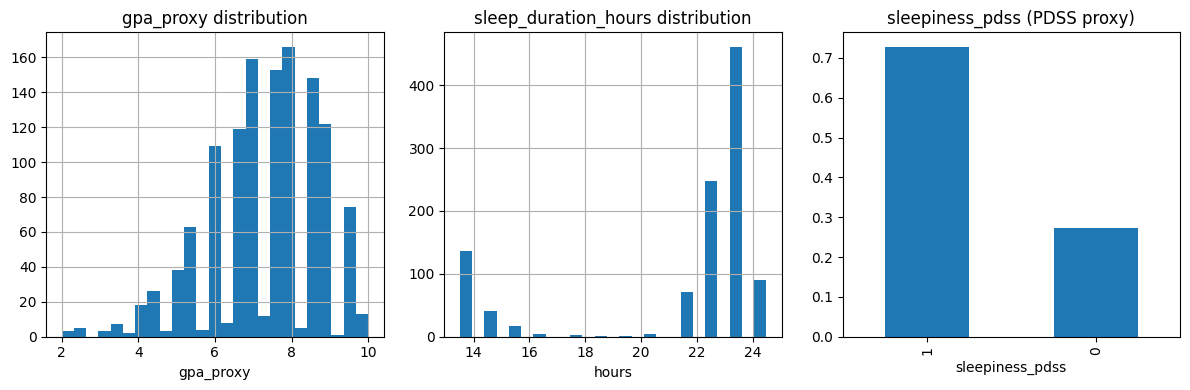

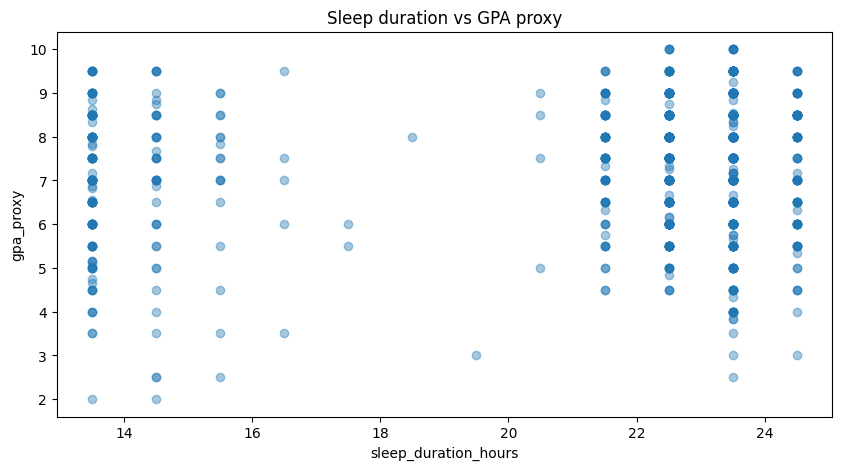

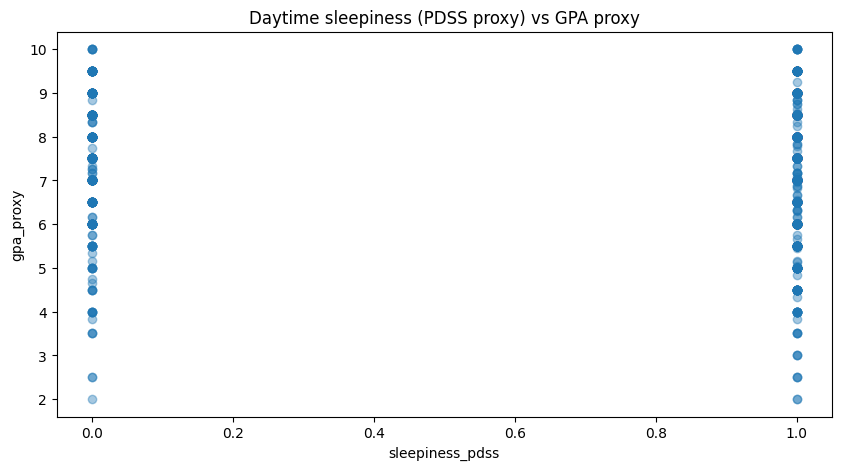

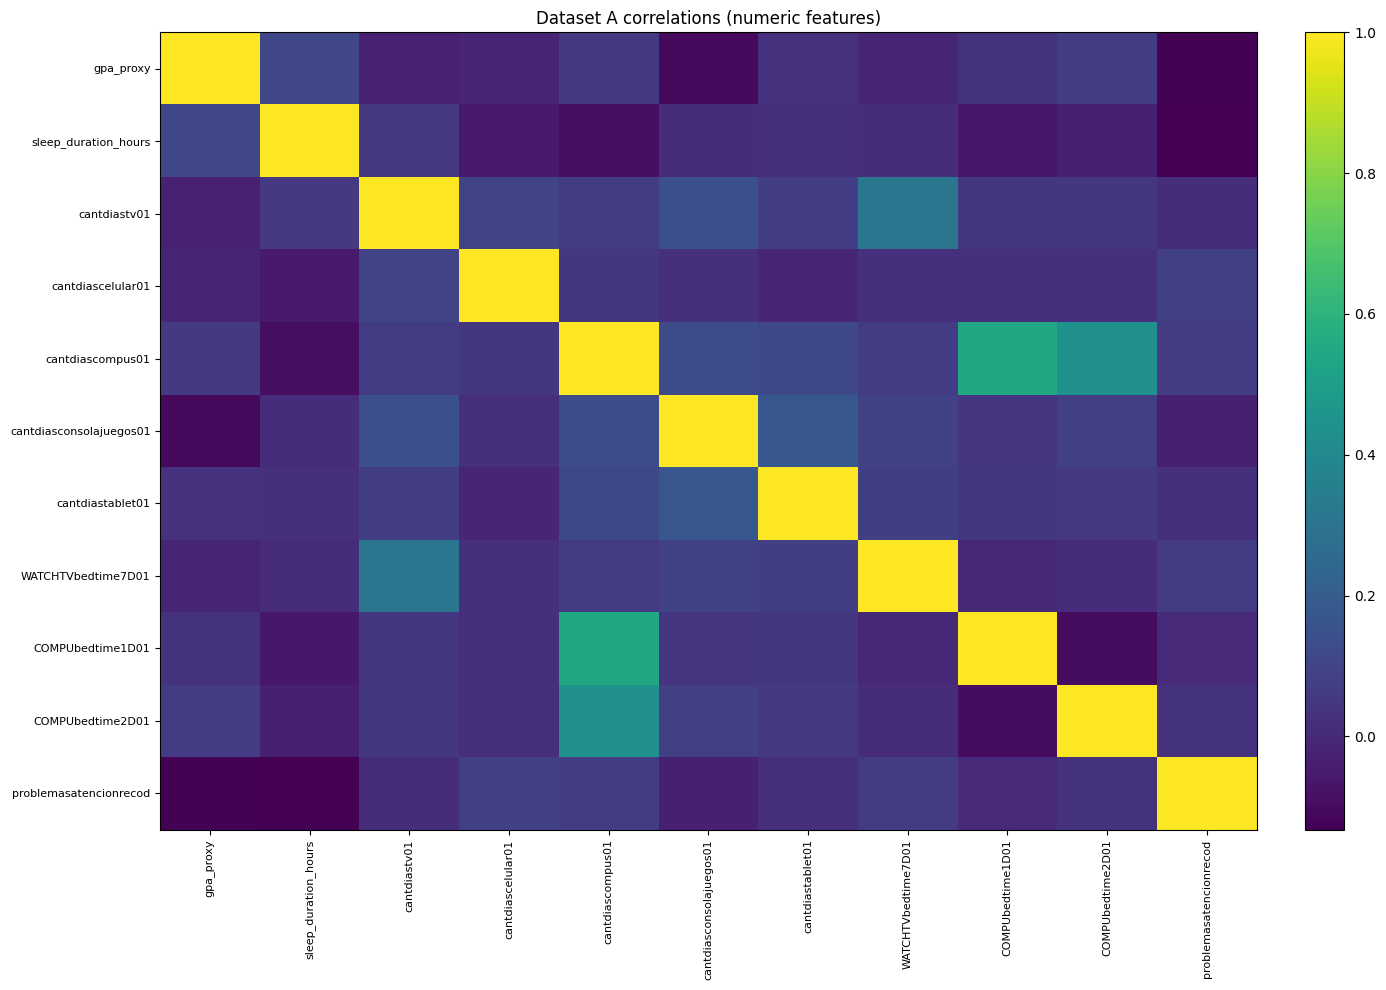

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/1041541882.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(k) for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())])


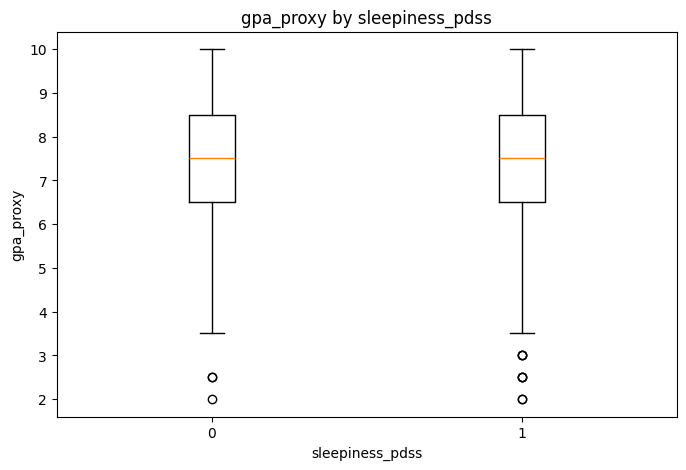

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


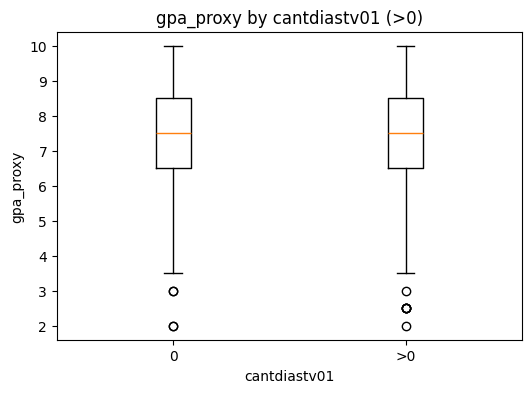

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


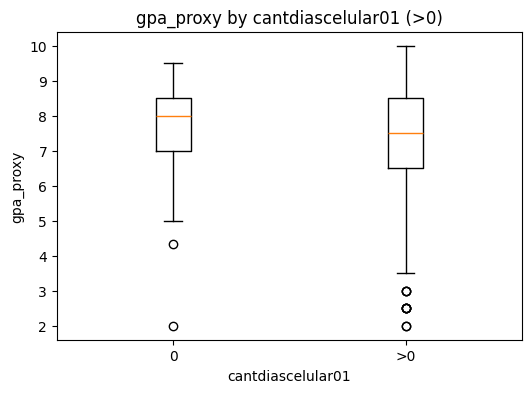

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


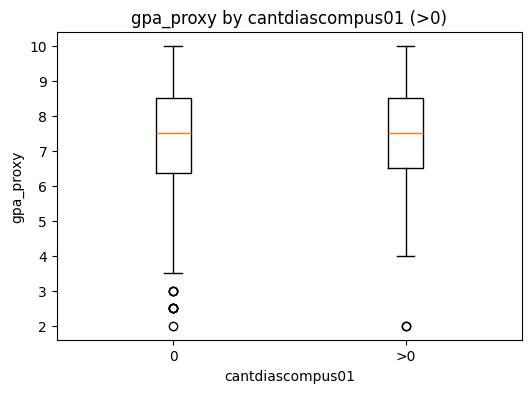

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


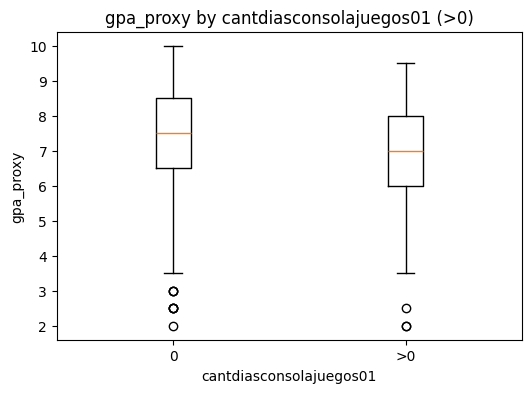

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


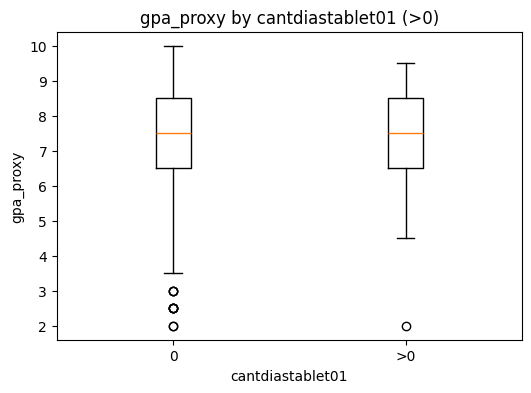

EDA complete for Dataset A


In [25]:
import matplotlib.pyplot as plt

# Guard: ensure wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

# Feature lists (from Dataset A wrangling)
screen_cols = [c for c in globals().get('A_screen_features', []) if c in A_model_df.columns]
sleep_cols = [c for c in globals().get('A_sleep_covariates', []) if c in A_model_df.columns]
behavior_cols = [c for c in globals().get('A_behavior_features', []) if c in A_model_df.columns]

print('EDA inputs')
print('  screen_cols:', screen_cols)
print('  sleep_cols:', sleep_cols)
print('  behavior_cols:', behavior_cols)

# -----------------------
# Summary tables
# -----------------------
summary_cols = ['gpa_proxy', 'sleep_duration_hours', 'sleepiness_pdss'] + screen_cols + behavior_cols
available_summary_cols = [c for c in summary_cols if c in A_model_df.columns]

print("\nMissingness (top) on available columns")
miss = A_model_df[available_summary_cols].isna().mean().sort_values(ascending=False)
print(miss.head(10))

print("\nGroup means by sleepiness_pdss")
group_sleep = A_model_df.groupby('sleepiness_pdss')[[
    'gpa_proxy', 'sleep_duration_hours'
]].mean(numeric_only=True)
print(group_sleep)

print("\nGroup means by screen_any (if available)")
# Define a simple screen_any proxy from day-count features if possible
screen_day_features = [c for c in screen_cols if c.startswith('cantdias')]
if screen_day_features:
    A_model_df['screen_any'] = (A_model_df[screen_day_features].fillna(0).sum(axis=1) > 0).astype(int)
    print(A_model_df.groupby('screen_any')[['gpa_proxy','sleep_duration_hours','sleepiness_pdss']].mean(numeric_only=True))
else:
    print('No screen day-count columns available; skipping screen_any.')

# -----------------------
# Distributions
# -----------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
A_model_df['gpa_proxy'].hist(bins=25)
plt.title('gpa_proxy distribution')
plt.xlabel('gpa_proxy')

plt.subplot(1, 3, 2)
A_model_df['sleep_duration_hours'].hist(bins=25)
plt.title('sleep_duration_hours distribution')
plt.xlabel('hours')

plt.subplot(1, 3, 3)
A_model_df['sleepiness_pdss'].value_counts(normalize=True).plot(kind='bar')
plt.title('sleepiness_pdss (PDSS proxy)')
plt.xlabel('sleepiness_pdss')

plt.tight_layout()
plt.show()

# -----------------------
# Relationship plots
# -----------------------
plt.figure(figsize=(10, 5))
plt.scatter(A_model_df['sleep_duration_hours'], A_model_df['gpa_proxy'], alpha=0.4)
plt.title('Sleep duration vs GPA proxy')
plt.xlabel('sleep_duration_hours')
plt.ylabel('gpa_proxy')
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(A_model_df['sleepiness_pdss'], A_model_df['gpa_proxy'], alpha=0.4)
plt.title('Daytime sleepiness (PDSS proxy) vs GPA proxy')
plt.xlabel('sleepiness_pdss')
plt.ylabel('gpa_proxy')
plt.show()

# -----------------------
# Correlation heatmap
# -----------------------
# Keep only numeric columns for correlations
corr_feature_candidates = ['gpa_proxy'] + sleep_cols + screen_cols + behavior_cols
corr_feature_candidates = [c for c in corr_feature_candidates if c in A_model_df.columns]

corr_df = A_model_df[corr_feature_candidates].copy()
# Convert constant columns to NaN correlations
corr = corr_df.corr(numeric_only=True)

# Drop rows/cols that are entirely NaN (e.g., constants)
mask_all_nan = corr.isna().all(axis=1) | corr.isna().all(axis=0)
if mask_all_nan.any():
    corr = corr.loc[~mask_all_nan, ~mask_all_nan]

plt.figure(figsize=(14, 10))
plt.imshow(corr.values, aspect='auto', interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title('Dataset A correlations (numeric features)')
plt.tight_layout()
plt.show()

# -----------------------
# Stratified comparisons
# -----------------------
# Boxplot GPA by sleepiness
plt.figure(figsize=(8, 5))
vals = [A_model_df.loc[A_model_df['sleepiness_pdss'] == k, 'gpa_proxy'] for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())]
plt.boxplot(vals, labels=[str(k) for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())])
plt.title('gpa_proxy by sleepiness_pdss')
plt.xlabel('sleepiness_pdss')
plt.ylabel('gpa_proxy')
plt.show()

# Boxplot GPA by each screen day-count (binarized)
for c in screen_day_features[:5]:
    # Convert to binary (any usage days)
    tmp = (A_model_df[c].fillna(0) > 0).astype(int)
    plt.figure(figsize=(6, 4))
    vals = [A_model_df.loc[tmp == k, 'gpa_proxy'] for k in [0,1]]
    plt.boxplot(vals, labels=['0','>0'])
    plt.title(f'gpa_proxy by {c} (>0)')
    plt.xlabel(c)
    plt.ylabel('gpa_proxy')
    plt.show()

print('EDA complete for Dataset A')


## A.4 Inference / Mediation-Style Workflow (Dataset A)

### Goal
Estimate whether **screen-use patterns** (exposure `X`) are associated with the academic outcome (**`gpa_proxy`**, outcome `Y`), and whether that relationship is **mediated by sleep characteristics** (mediator `M`).

This implements a **mediation-style linear workflow** using multivariable regression and reports uncertainty via both:
- **Bootstrap CIs** for path coefficients and indirect effects
- **Permutation testing** (randomized exposure) to gauge how unusual the indirect effect is under a null association structure

### Model (linear mediation-style)
For a chosen mediator `M` (sleep feature):

1. **Mediator model**:  `M = a * X + Cov + e`
2. **Outcome model**:   `Y = c' * X + b * M + Cov + u`

Derived effects:
- **Direct effect**: `c'`
- **Total effect**: `c` (from `Y = c * X + Cov`)
- **Indirect (mediated) effect**: `a*b`

### What we use as `X`, `M`, and covariates
- `X` (screen exposure) is a **composite index** built from Dataset A screen-use features (`A_screen_features`) and standardized to **1 SD** within the analysis sample.
- We run mediation **separately** for two sleep constructs:
  - Mediator 1: `sleepiness_pdss`, controlling for `sleep_duration_hours`
  - Mediator 2: `sleep_duration_hours`, controlling for `sleepiness_pdss`
- Optional covariate(s): Dataset A behavioral proxy `problemasatencionrecod` when available.

### Diagnostics included in the code cell
- Residual plots and Q-Q plots for mediator + outcome regressions
- Multicollinearity check via **VIF** for predictors in the outcome model

### Interpretation checklist (read after running)
- If the **bootstrap CI** for the indirect effect `a*b` excludes 0, that supports a mediated *association* between screen-use and GPA via sleep.
- The **permutation p-value** summarizes how often a similarly large indirect effect occurs under a randomized exposure null.
- Because the dataset is effectively cross-sectional/self-report, interpret results as **mediation-style evidence**, not definitive causal mediation, unless assumptions about timing and confounding are satisfied.


Dataset A mediation run: M='sleepiness_pdss', Cov=['problemasatencionrecod', 'sleep_duration_hours']
Complete-case n=1078
Path estimates: a (X->M)=-0.0033, b (M->Y|X)=0.0231
Effects: indirect=a*b=-0.0001, direct c'=0.0144, total c=0.0143
VIF (outcome model predictors):
problemasatencionrecod    1.286469
M                         1.267421
sleep_duration_hours      1.018484
X_std                     1.004642


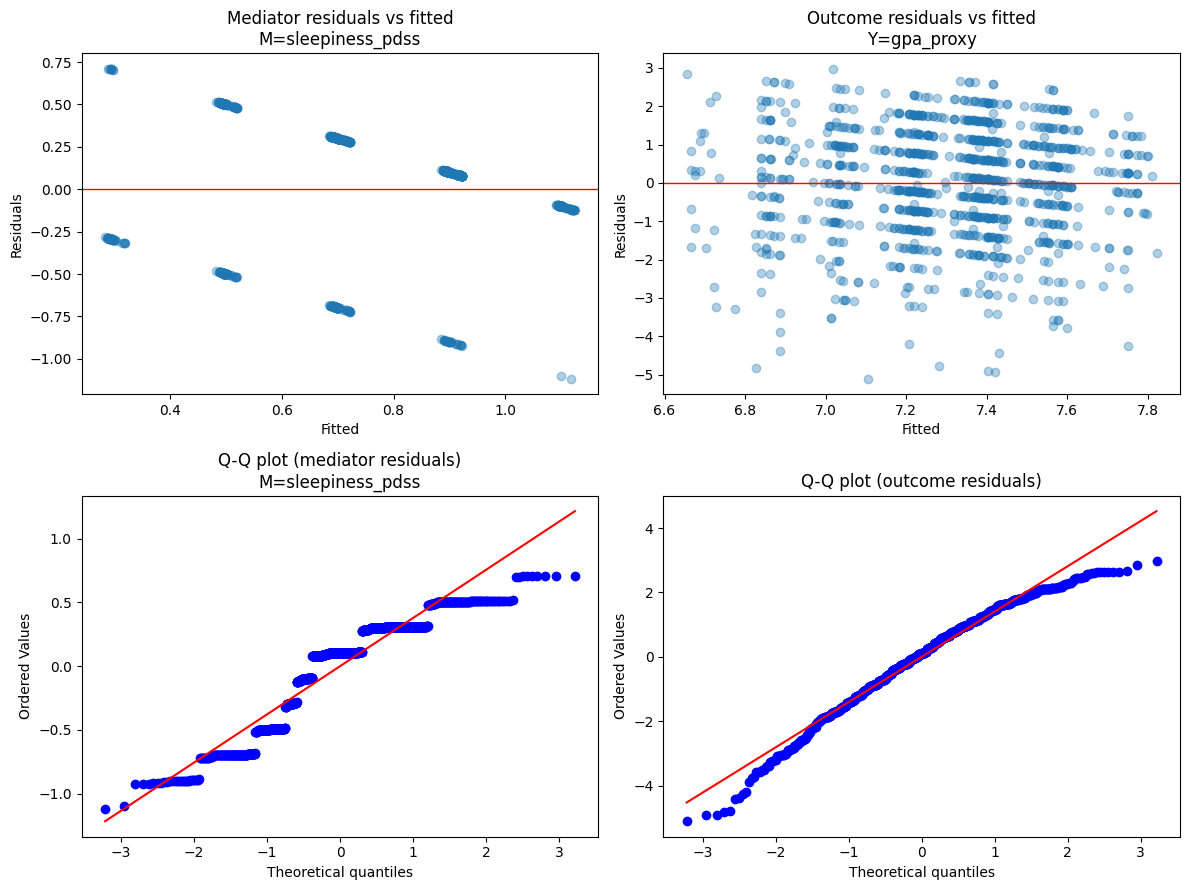


Dataset A mediation run: M='sleep_duration_hours', Cov=['problemasatencionrecod', 'sleepiness_pdss']
Complete-case n=1078
Path estimates: a (X->M)=-0.0531, b (M->Y|X)=0.0367
Effects: indirect=a*b=-0.0020, direct c'=0.0144, total c=0.0124
VIF (outcome model predictors):
problemasatencionrecod    1.286469
sleepiness_pdss           1.267421
M                         1.018484
X_std                     1.004642


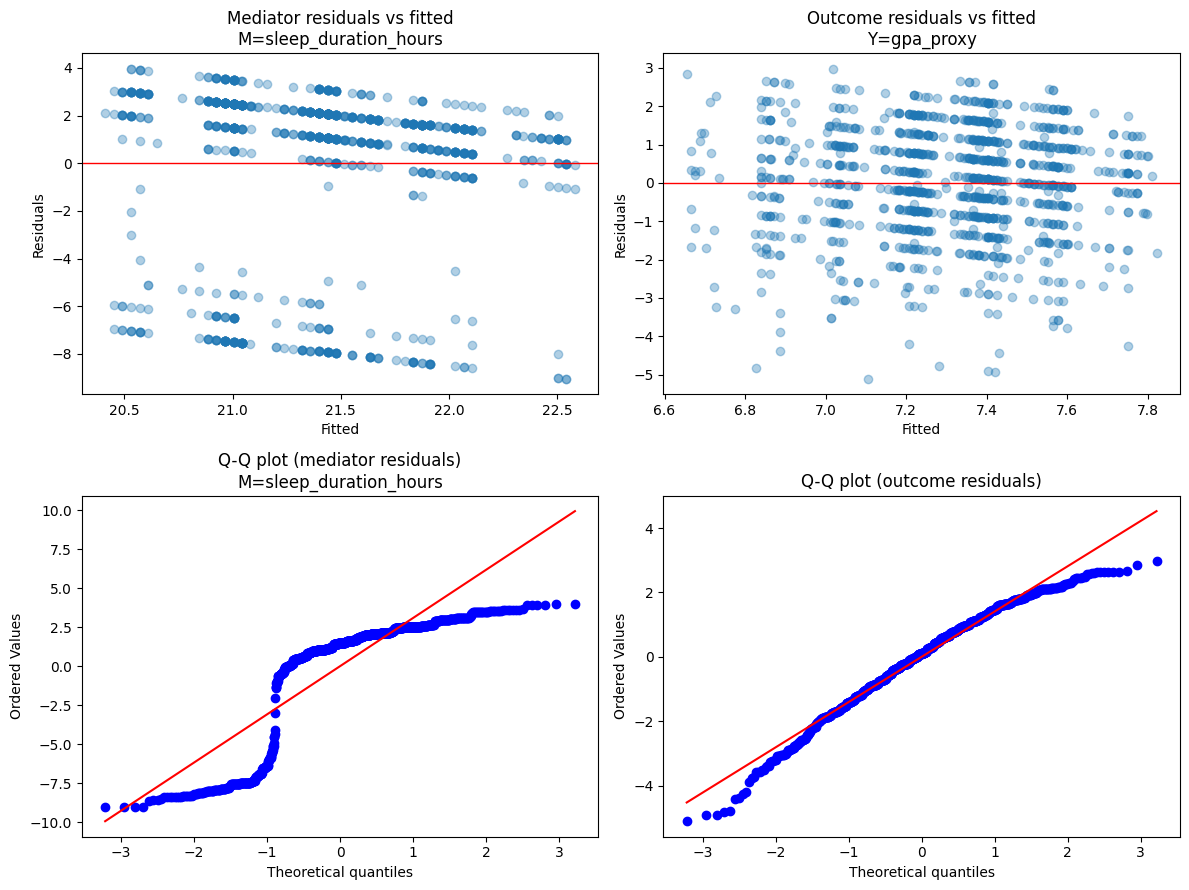


Dataset A mediation summary (screen -> sleep -> GPA proxy)
            mediator  n_complete_cases     a_hat  a_ci_low  a_ci_high    b_hat  b_ci_low  b_ci_high  c_prime_hat  c_prime_ci_low  c_prime_ci_high  c_total_hat  c_total_ci_low  c_total_ci_high  indirect_hat  indirect_ci_low  indirect_ci_high  perm_p_value  boot_succ  perm_succ                        covariates_in_models
sleep_duration_hours              1078 -0.053104 -0.297792   0.172410 0.036735  0.010409   0.064423     0.014374       -0.065821         0.084679     0.012424       -0.067567         0.085847     -0.001951        -0.010975          0.006004      0.643564        300        100      problemasatencionrecod,sleepiness_pdss
     sleepiness_pdss              1078 -0.003272 -0.029674   0.021527 0.023143 -0.191890   0.204963     0.014374       -0.073391         0.096389     0.014299       -0.071998         0.096109     -0.000076        -0.003781          0.002917      0.851485        300        100 problemasatencionreco

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels is preferred; if unavailable, fall back to a lightweight numpy-based OLS
try:
    import statsmodels.api as sm  # type: ignore
except ModuleNotFoundError:
    from scipy import stats as _scipy_stats

    def _add_constant(X, has_constant: str = 'add'):
        """Minimal replacement for statsmodels.api.add_constant."""
        if isinstance(X, pd.DataFrame):
            if 'const' in X.columns:
                return X
            out = X.copy()
            out.insert(0, 'const', 1.0)
            return out
        X_arr = np.asarray(X, dtype=float)
        ones = np.ones((X_arr.shape[0], 1), dtype=float)
        return np.hstack([ones, X_arr])

    class _OLSResult:
        def __init__(self, params, fittedvalues, resid, rsquared):
            self.params = params
            self.fittedvalues = fittedvalues
            self.resid = resid
            self.rsquared = rsquared

    class _OLSModel:
        def __init__(self, endog, exog):
            self.endog = np.asarray(endog, dtype=float)
            self.exog_is_df = isinstance(exog, pd.DataFrame)
            self.exog_df = exog if self.exog_is_df else None
            self.exog_mat = exog.values.astype(float) if self.exog_is_df else np.asarray(exog, dtype=float)
            self.param_names = list(self.exog_df.columns) if self.exog_is_df else None

        def fit(self):
            beta = np.linalg.lstsq(self.exog_mat, self.endog, rcond=None)[0]
            fitted = self.exog_mat @ beta
            resid = self.endog - fitted
            ss_res = float(np.sum(resid ** 2))
            y = self.endog
            ss_tot = float(np.sum((y - y.mean()) ** 2))
            rsq = (1.0 - ss_res / ss_tot) if ss_tot != 0 else 0.0
            params = pd.Series(beta, index=self.param_names) if self.param_names is not None else beta
            return _OLSResult(params=params, fittedvalues=fitted, resid=resid, rsquared=rsq)

    def _OLS(endog, exog):
        return _OLSModel(endog=endog, exog=exog)

    def _qqplot(x, line: str = '45', ax=None):
        if ax is None:
            ax = plt.gca()
        _scipy_stats.probplot(x, dist='norm', plot=ax)
        return ax

    class _SMWrapper:
        add_constant = staticmethod(_add_constant)
        OLS = staticmethod(_OLS)
        qqplot = staticmethod(_qqplot)

    sm = _SMWrapper()

# -----------------------
# Parameters (adjust if runtime is too slow)
# -----------------------
N_BOOT = 300
N_PERM = 100
SEED = 42

# Guard: ensure wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

# -----------------------
# Exposure / feature definitions
# -----------------------
Y_COL = 'gpa_proxy'

screen_features = [c for c in globals().get('A_screen_features', []) if c in A_model_df.columns]
if not screen_features:
    raise RuntimeError("No screen features found in globals(). Expected A_screen_features from Dataset A wrangling.")

behavior_features = [c for c in globals().get('A_behavior_features', []) if c in A_model_df.columns]

BASE_DF = A_model_df.copy()

# Screen exposure composite (sum across features); missing screen values are treated as 0.
BASE_DF['screen_exposure_raw'] = BASE_DF[screen_features].fillna(0).sum(axis=1)

# Optional covariate(s)
COV_BASE = []
for c in behavior_features:
    if c not in COV_BASE:
        COV_BASE.append(c)

# Two sleep mediators; we run them separately for interpretability.
MEDIATOR_SPECS = [
    ('sleepiness_pdss', 'sleep_duration_hours'),  # M, covariate
    ('sleep_duration_hours', 'sleepiness_pdss'),  # M, covariate
]


def _standardize_1sd(x: pd.Series) -> pd.Series:
    """Standardize to mean=0, sd=1 (within a given analysis sample)."""
    x = pd.to_numeric(x, errors='coerce')
    sd = x.std(ddof=0)
    if sd is None or sd == 0 or np.isnan(sd):
        return x * 0.0
    return (x - x.mean()) / sd


def _fit_ols_models(df_work: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    """Fit: M~X+Cov and Y~X+M+Cov (X is standardized internally)."""
    df_work = df_work.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()

    # Standardize X within the (already complete-case) analysis sample
    df_work['X_std'] = _standardize_1sd(df_work['screen_exposure_raw'])

    y = df_work[Y_COL].astype(float).values
    m = df_work[mediator_col].astype(float).values

    # Mediator model: M ~ X + Cov
    X_m = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_work[c].values
    X_m = sm.add_constant(X_m, has_constant='add')
    model_m = sm.OLS(m, X_m).fit()
    a = float(model_m.params['x'])

    # Outcome model: Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_work['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_work[c].values
    X_y = sm.add_constant(X_y, has_constant='add')
    model_y = sm.OLS(y, X_y).fit()
    b = float(model_y.params['m'])
    c_prime = float(model_y.params['x'])

    # Total effect model: Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_work[c].values
    X_t = sm.add_constant(X_t, has_constant='add')
    model_t = sm.OLS(y, X_t).fit()
    c_total = float(model_t.params['x'])

    indirect = a * b

    return {
        'n': int(df_work.shape[0]),
        'a': a,
        'b': b,
        'c_prime': c_prime,
        'c_total': c_total,
        'indirect': indirect,
        'model_m': model_m,
        'model_y': model_y,
        'model_t': model_t,
        'df_work': df_work,
    }


def _vif(df_design: pd.DataFrame) -> pd.Series:
    """Variance Inflation Factor for numeric predictors (no constant required)."""
    # df_design: columns are predictors
    from numpy.linalg import LinAlgError

    vifs = {}
    for col in df_design.columns:
        y = df_design[col].astype(float).values
        X = df_design.drop(columns=[col]).astype(float)
        if X.shape[1] == 0:
            vifs[col] = np.nan
            continue
        try:
            r2 = sm.OLS(y, sm.add_constant(X, has_constant='add')).fit().rsquared
            vifs[col] = float(1.0 / (1.0 - r2)) if (1.0 - r2) != 0 else np.inf
        except LinAlgError:
            vifs[col] = np.inf
    return pd.Series(vifs)


def _compute_effects(df_sample: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    """Compute (a, b, c_prime, c_total, indirect) for one dataset draw."""
    df_sample = df_sample.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()
    if df_sample.shape[0] < 30:
        return None

    df_sample['X_std'] = _standardize_1sd(df_sample['screen_exposure_raw'])

    y = df_sample[Y_COL].astype(float).values
    m = df_sample[mediator_col].astype(float).values

    # M ~ X + Cov
    X_m = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_sample[c].values
    X_m = sm.add_constant(X_m, has_constant='add')
    model_m = sm.OLS(m, X_m).fit()
    a = float(model_m.params['x'])

    # Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_sample['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_sample[c].values
    X_y = sm.add_constant(X_y, has_constant='add')
    model_y = sm.OLS(y, X_y).fit()
    b = float(model_y.params['m'])
    c_prime = float(model_y.params['x'])

    # Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_sample[c].values
    X_t = sm.add_constant(X_t, has_constant='add')
    model_t = sm.OLS(y, X_t).fit()
    c_total = float(model_t.params['x'])

    indirect = a * b

    return a, b, c_prime, c_total, indirect


rng = np.random.default_rng(SEED)
results_rows = []

for mediator_col, other_sleep_cov in MEDIATOR_SPECS:
    if mediator_col not in BASE_DF.columns:
        print(f"Skipping mediator '{mediator_col}': missing column")
        continue

    cov_cols = list(COV_BASE)
    if other_sleep_cov in BASE_DF.columns:
        # Include the other sleep construct as a covariate so we can interpret M separately.
        cov_cols = cov_cols + [other_sleep_cov]

    # Complete-case base for this mediation run
    base_df = BASE_DF[[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols].dropna().copy()
    n = int(base_df.shape[0])
    if n < 100:
        print(f"WARNING: mediation run for mediator='{mediator_col}' has small n={n} complete cases.")

    # Observed fits + diagnostics
    observed = _fit_ols_models(base_df, mediator_col=mediator_col, cov_cols=cov_cols)

    # VIF on outcome-model predictors (X_std, M, plus Cov)
    dfv = observed['df_work'].copy()
    dfv['X_std'] = _standardize_1sd(dfv['screen_exposure_raw'])
    design_out = pd.DataFrame({'X_std': dfv['X_std'].values, 'M': dfv[mediator_col].astype(float).values})
    for c in cov_cols:
        design_out[c] = dfv[c].values
    vif = _vif(design_out)

    print("\n" + "="*80)
    print(f"Dataset A mediation run: M='{mediator_col}', Cov={cov_cols}")
    print(f"Complete-case n={observed['n']}")
    print(f"Path estimates: a (X->M)={observed['a']:.4f}, b (M->Y|X)={observed['b']:.4f}")
    print(f"Effects: indirect=a*b={observed['indirect']:.4f}, direct c'={observed['c_prime']:.4f}, total c={observed['c_total']:.4f}")
    print("VIF (outcome model predictors):")
    print(vif.sort_values(ascending=False).to_string())

    # Bootstrap uncertainty
    boot_effects = []
    boot_indirect = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        sample_df = base_df.iloc[idx]
        eff = _compute_effects(sample_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        a, b, c_prime, c_total, indirect = eff
        boot_effects.append((a, b, c_prime, c_total, indirect))
        boot_indirect.append(indirect)

    boot_effects = np.array(boot_effects, dtype=float)
    if boot_effects.shape[0] < max(50, N_BOOT * 0.5):
        print(f"WARNING: bootstrap draws succeeded={boot_effects.shape[0]} / {N_BOOT} for mediator='{mediator_col}'")

    def _ci(x: np.ndarray, alpha: float = 0.05):
        lo = np.nanpercentile(x, 100 * (alpha/2))
        hi = np.nanpercentile(x, 100 * (1 - alpha/2))
        return float(lo), float(hi)

    a_boot = boot_effects[:, 0]
    b_boot = boot_effects[:, 1]
    c_prime_boot = boot_effects[:, 2]
    c_total_boot = boot_effects[:, 3]
    indirect_boot = boot_effects[:, 4]

    a_ci = _ci(a_boot)
    b_ci = _ci(b_boot)
    c_prime_ci = _ci(c_prime_boot)
    c_total_ci = _ci(c_total_boot)
    indirect_ci = _ci(indirect_boot)

    # Permutation null for indirect effect
    perm_indirect = []
    x_values = base_df['screen_exposure_raw'].astype(float).values
    for _ in range(N_PERM):
        perm_x = rng.permutation(x_values)
        perm_df = base_df.copy()
        perm_df['screen_exposure_raw'] = perm_x
        eff = _compute_effects(perm_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        perm_indirect.append(eff[-1])

    perm_indirect = np.array(perm_indirect, dtype=float)
    # Two-sided permutation p-value using absolute magnitude
    p_perm = (np.sum(np.abs(perm_indirect) >= abs(observed['indirect'])) + 1) / (len(perm_indirect) + 1)

    results_rows.append({
        'mediator': mediator_col,
        'n_complete_cases': observed['n'],
        'a_hat': observed['a'],
        'a_ci_low': a_ci[0],
        'a_ci_high': a_ci[1],
        'b_hat': observed['b'],
        'b_ci_low': b_ci[0],
        'b_ci_high': b_ci[1],
        'c_prime_hat': observed['c_prime'],
        'c_prime_ci_low': c_prime_ci[0],
        'c_prime_ci_high': c_prime_ci[1],
        'c_total_hat': observed['c_total'],
        'c_total_ci_low': c_total_ci[0],
        'c_total_ci_high': c_total_ci[1],
        'indirect_hat': observed['indirect'],
        'indirect_ci_low': indirect_ci[0],
        'indirect_ci_high': indirect_ci[1],
        'perm_p_value': p_perm,
        'boot_succ': int(boot_effects.shape[0]),
        'perm_succ': int(perm_indirect.shape[0]),
        'covariates_in_models': ','.join(cov_cols),
    })

    # -----------------------
    # Diagnostics plots (observed sample)
    # -----------------------
    model_m = observed['model_m']
    model_y = observed['model_y']

    # Mediator residuals
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # Residuals vs fitted (mediator)
    axes[0, 0].scatter(model_m.fittedvalues, model_m.resid, alpha=0.35)
    axes[0, 0].axhline(0, color='red', linewidth=1)
    axes[0, 0].set_title(f"Mediator residuals vs fitted\nM={mediator_col}")
    axes[0, 0].set_xlabel('Fitted')
    axes[0, 0].set_ylabel('Residuals')

    # Residuals vs fitted (outcome)
    axes[0, 1].scatter(model_y.fittedvalues, model_y.resid, alpha=0.35)
    axes[0, 1].axhline(0, color='red', linewidth=1)
    axes[0, 1].set_title(f"Outcome residuals vs fitted\nY=gpa_proxy")
    axes[0, 1].set_xlabel('Fitted')
    axes[0, 1].set_ylabel('Residuals')

    # Q-Q plot (mediator residuals)
    sm.qqplot(model_m.resid, line='45', ax=axes[1, 0])
    axes[1, 0].set_title(f"Q-Q plot (mediator residuals)\nM={mediator_col}")

    # Q-Q plot (outcome residuals)
    sm.qqplot(model_y.resid, line='45', ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q plot (outcome residuals)")

    plt.tight_layout()
    plt.show()


A_mediation_results = pd.DataFrame(results_rows)
A_mediation_results = A_mediation_results.sort_values('mediator')

print("\n" + "="*80)
print("Dataset A mediation summary (screen -> sleep -> GPA proxy)")
print(A_mediation_results.to_string(index=False))

# Keep results in notebook globals for later comparison/plots
A_mediation_results_df = A_mediation_results


## How to read the Dataset A mediation output

After running the workflow cell, focus on the table printed as `Dataset A mediation summary (screen -> sleep -> GPA proxy)`:

- `indirect_hat` is the **estimated mediated (indirect) association** `a*b`.
- `indirect_ci_low` / `indirect_ci_high` is the **bootstrap 95% CI** for the indirect effect.
- `perm_p_value` is a **permutation p-value** based on how often an indirect effect of equal-or-greater magnitude appears after randomizing the exposure (`X`).

Residual plots + Q-Q plots are diagnostic checks for whether linear model residuals look approximately well-behaved; VIF helps flag multicollinearity among predictors in the outcome regression.

If you want to strengthen robustness in the next iteration, we can (a) add more covariates, (b) define alternative screen-exposure composites, and/or (c) increase `N_BOOT` / `N_PERM`.

## A.5 Prediction & Feature-Group Ablations (RQ3) (Dataset A)

Goal: predict the **GPA proxy** (`gpa_proxy`) from Dataset A features using supervised ML with:
- **Cross-validation** performance estimates
- **Baselines** (mean/OLS)
- **Regularized models** (RidgeCV and ElasticNetCV)
- **Feature-group ablations** comparing `screen-only` vs `sleep-only` vs `combined`
- **Interpretability** via (a) linear coefficient magnitude and (b) permutation feature importance

Outputs (dataframes) produced by the code cell:
- `A_ml_cv_summary` (CV metrics by model and feature group)
- `A_ml_oof_predictions` (out-of-fold predictions for the chosen best model on the combined feature set)
- `A_ml_feature_importance` (top features for the best combined regularized model)


Evaluating feature group: screen_only (n_features=8)
               model   r2_mean  rmse_mean
       ridge_ridgecv  0.007244   1.428673
                 ols  0.005909   1.429616
elastic_elasticnetcv  0.005083   1.430207
       baseline_mean -0.002999   1.435832

Evaluating feature group: sleep_only (n_features=2)
               model   r2_mean  rmse_mean
       ridge_ridgecv  0.006379   1.429538
                 ols  0.006224   1.429690
elastic_elasticnetcv  0.000693   1.433441
       baseline_mean -0.002999   1.435832

Evaluating feature group: combined (n_features=11)
               model   r2_mean  rmse_mean
       ridge_ridgecv  0.032340   1.411082
                 ols  0.031115   1.411977
elastic_elasticnetcv  0.028701   1.413619
       baseline_mean -0.002999   1.435832

Dataset A supervised prediction summary (CV)
feature_group                model  n_features  rmse_mean  rmse_std  mae_mean   r2_mean   r2_std
     combined        ridge_ridgecv          11   1.411082  0.123962 

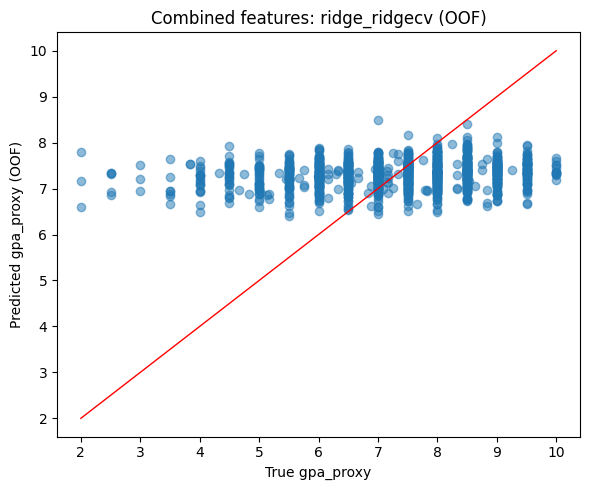


Top feature importance (combined, best regularized model):
                feature      coef  abs_coef  perm_importance_mean  perm_importance_std
 problemasatencionrecod -0.177203  0.177203              0.031765             0.006959
cantdiasconsolajuegos01 -0.163226  0.163226              0.024782             0.004157
   sleep_duration_hours  0.123385  0.123385              0.016674             0.004073
       COMPUbedtime2D01  0.077371  0.077371              0.006330             0.002735
       cantdiascompus01  0.066548  0.066548              0.004897             0.002209
       cantdiastablet01  0.055982  0.055982              0.003484             0.000899
           cantdiastv01 -0.035125  0.035125              0.001065             0.001015
       COMPUbedtime1D01  0.034116  0.034116              0.001136             0.001097
        sleepiness_pdss  0.021125  0.021125              0.000389             0.001078
     WATCHTVbedtime7D01  0.004877  0.004877              0.000087     

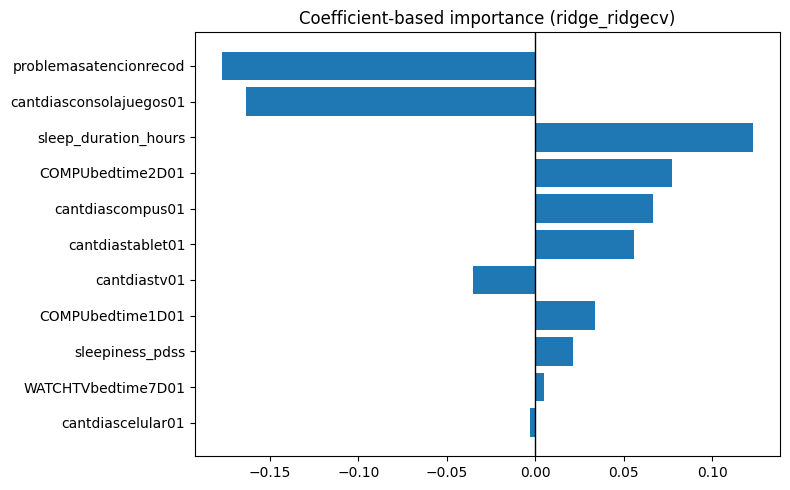

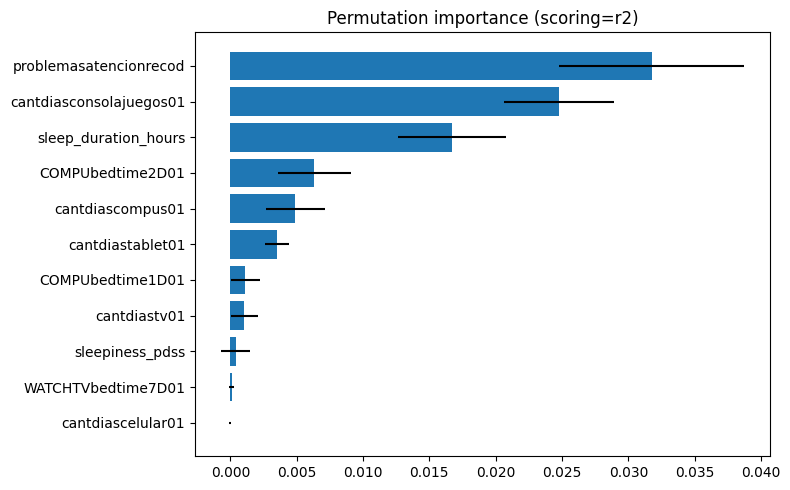

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

SEED = 42
N_SPLITS = 5

# Guard: ensure Dataset A wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

Y_COL = 'gpa_proxy'

df_ml = A_model_df.copy()
if Y_COL not in df_ml.columns:
    raise RuntimeError(f"Missing target '{Y_COL}' in A_model_df")

df_ml = df_ml.dropna(subset=[Y_COL]).copy()

# Feature groups
screen_features = [c for c in globals().get('A_screen_features', []) if c in df_ml.columns]
sleep_features = [c for c in ['sleep_duration_hours', 'sleepiness_pdss'] if c in df_ml.columns]
behavior_features = [c for c in globals().get('A_behavior_features', []) if c in df_ml.columns]

combined_features = list(dict.fromkeys(screen_features + sleep_features + behavior_features))

feature_groups = {
    'screen_only': screen_features,
    'sleep_only': sleep_features,
    'combined': combined_features,
}

# Sanity checks
for k, cols in feature_groups.items():
    if len(cols) == 0:
        raise RuntimeError(f"Feature group '{k}' has no columns. Check Dataset A wrangling.")

# CV folds (shared across ablations for fair comparison)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(kf.split(df_ml))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_group(group_name: str, cols: list[str]):
    X = df_ml[cols]
    y = df_ml[Y_COL].astype(float).values

    # Pipelines
    ridge_alphas = np.logspace(-2, 2, 9)  # 0.01 ... 100
    elastic_alphas = np.logspace(-3, 0, 7)  # 0.001 ... 1
    elastic_l1_ratios = [0.1, 0.5, 0.9]

    def make_dummy():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', DummyRegressor(strategy='mean')),
        ])

    def make_ols():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', LinearRegression()),
        ])

    def make_ridge():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', RidgeCV(alphas=ridge_alphas, cv=5)),
        ])

    def make_elastic():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', ElasticNetCV(alphas=elastic_alphas, l1_ratio=elastic_l1_ratios, cv=5, max_iter=100000, random_state=SEED)),
        ])

    model_builders = {
        'baseline_mean': make_dummy,
        'ols': make_ols,
        'ridge_ridgecv': make_ridge,
        'elastic_elasticnetcv': make_elastic,
    }

    results = []
    # Store out-of-fold predictions for the combined group later for the best model
    oof_preds_by_model = {name: np.full_like(y, fill_value=np.nan, dtype=float) for name in model_builders}

    for model_name, make_model in model_builders.items():
        fold_rmses, fold_maes, fold_r2s = [], [], []

        for fold_i, (train_idx, test_idx) in enumerate(folds):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = make_model()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            oof_preds_by_model[model_name][test_idx] = y_pred

            fold_rmses.append(rmse(y_test, y_pred))
            fold_maes.append(float(mean_absolute_error(y_test, y_pred)))
            fold_r2s.append(float(r2_score(y_test, y_pred)))

        results.append({
            'feature_group': group_name,
            'model': model_name,
            'n_features': int(len(cols)),
            'rmse_mean': float(np.mean(fold_rmses)),
            'rmse_std': float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0,
            'mae_mean': float(np.mean(fold_maes)),
            'r2_mean': float(np.mean(fold_r2s)),
            'r2_std': float(np.std(fold_r2s, ddof=1)) if len(fold_r2s) > 1 else 0.0,
        })

    results_df = pd.DataFrame(results).sort_values('r2_mean', ascending=False)
    return results_df, oof_preds_by_model, X, y


all_rows = []
oof_predictions_store = {}
X_store = {}
y_store = {}

for group_name, cols in feature_groups.items():
    print(f"\nEvaluating feature group: {group_name} (n_features={len(cols)})")
    res_df, oof_preds_by_model, X, y = evaluate_group(group_name, cols)
    print(res_df[['model', 'r2_mean', 'rmse_mean']].to_string(index=False))

    all_rows.append(res_df)
    oof_predictions_store[group_name] = oof_preds_by_model
    X_store[group_name] = X
    y_store[group_name] = y

A_ml_cv_summary = pd.concat(all_rows, ignore_index=True)
A_ml_cv_summary = A_ml_cv_summary.sort_values(['feature_group', 'r2_mean'], ascending=[True, False])

print("\n" + "="*80)
print("Dataset A supervised prediction summary (CV)")
print(A_ml_cv_summary.to_string(index=False))

# Choose best model on combined regularized family (ridge/elastic) for interpretability + plots
combined_summary = A_ml_cv_summary[A_ml_cv_summary['feature_group'] == 'combined']
regularized = combined_summary[combined_summary['model'].isin(['ridge_ridgecv', 'elastic_elasticnetcv'])]

if len(regularized) > 0:
    best_model_name = regularized.sort_values('r2_mean', ascending=False).iloc[0]['model']
else:
    best_model_name = combined_summary.sort_values('r2_mean', ascending=False).iloc[0]['model']

print("\nBest combined model for interpretability:", best_model_name)

# Get combined OOF predictions for the best model
X_comb = X_store['combined']
y_comb = y_store['combined']
oof_pred_comb = oof_predictions_store['combined'][best_model_name]

A_ml_oof_predictions = pd.DataFrame({
    'y_true': y_comb,
    'y_pred': oof_pred_comb,
})

# Plot: y_true vs y_pred
plt.figure(figsize=(6, 5))
plt.scatter(A_ml_oof_predictions['y_true'], A_ml_oof_predictions['y_pred'], alpha=0.5)
minv = float(min(A_ml_oof_predictions['y_true'].min(), A_ml_oof_predictions['y_pred'].min()))
maxv = float(max(A_ml_oof_predictions['y_true'].max(), A_ml_oof_predictions['y_pred'].max()))
plt.plot([minv, maxv], [minv, maxv], color='red', linewidth=1)
plt.xlabel('True gpa_proxy')
plt.ylabel('Predicted gpa_proxy (OOF)')
plt.title(f'Combined features: {best_model_name} (OOF)')
plt.tight_layout()
plt.show()

# Fit the best model on the full combined dataset for coefficient/permutation importance
cols_comb = feature_groups['combined']
X_full = X_comb

ridge_alphas = np.logspace(-2, 2, 9)
elastic_alphas = np.logspace(-3, 0, 7)
elastic_l1_ratios = [0.1, 0.5, 0.9]

if best_model_name == 'ridge_ridgecv':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=ridge_alphas, cv=5)),
    ])
elif best_model_name == 'elastic_elasticnetcv':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', ElasticNetCV(alphas=elastic_alphas, l1_ratio=elastic_l1_ratios, cv=5, max_iter=100000, random_state=SEED)),
    ])
else:
    # Fallback: OLS
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LinearRegression()),
    ])

final_model.fit(X_full, y_comb)

# Coefficient-based feature ranking (for linear regularized models)
coef_importance_df = None
if hasattr(final_model.named_steps['model'], 'coef_'):
    coefs = final_model.named_steps['model'].coef_
    coef_importance_df = pd.DataFrame({
        'feature': cols_comb,
        'coef': coefs,
        'abs_coef': np.abs(coefs),
    }).sort_values('abs_coef', ascending=False)

# Permutation importance (agnostic)
perm_importance_df = None
try:
    perm = permutation_importance(final_model, X_full, y_comb, n_repeats=15, random_state=SEED, scoring='r2')
    perm_importance_df = pd.DataFrame({
        'feature': cols_comb,
        'perm_importance_mean': perm.importances_mean,
        'perm_importance_std': perm.importances_std,
    }).sort_values('perm_importance_mean', ascending=False)
except Exception as e:
    print("Permutation importance failed:", repr(e))

# Combine importance tables
if coef_importance_df is not None and perm_importance_df is not None:
    A_ml_feature_importance = coef_importance_df.merge(perm_importance_df, on='feature', how='left')
elif coef_importance_df is not None:
    A_ml_feature_importance = coef_importance_df
elif perm_importance_df is not None:
    A_ml_feature_importance = perm_importance_df
else:
    A_ml_feature_importance = pd.DataFrame({'feature': cols_comb})

A_ml_feature_importance = A_ml_feature_importance.reset_index(drop=True)
print("\nTop feature importance (combined, best regularized model):")
print(A_ml_feature_importance.head(15).to_string(index=False))

# Plot: top coefficient magnitudes (if available)
if coef_importance_df is not None:
    topk = min(12, len(coef_importance_df))
    plt.figure(figsize=(8, 5))
    tmp = coef_importance_df.head(topk).iloc[::-1]
    plt.barh(tmp['feature'], tmp['coef'])
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f'Coefficient-based importance ({best_model_name})')
    plt.tight_layout()
    plt.show()

# Plot: permutation importance (if available)
if perm_importance_df is not None:
    topk = min(12, len(perm_importance_df))
    plt.figure(figsize=(8, 5))
    tmp = perm_importance_df.head(topk).iloc[::-1]
    plt.barh(tmp['feature'], tmp['perm_importance_mean'], xerr=tmp['perm_importance_std'])
    plt.title('Permutation importance (scoring=r2)')
    plt.tight_layout()
    plt.show()


## How to interpret Dataset A prediction + ablation results

1. **Predictive value by feature group**: compare `r2_mean` (and RMSE) across `screen_only` vs `sleep_only` vs `combined`.
   - If `combined` is substantially better, sleep likely adds information beyond screen features (in prediction terms).

2. **Regularization sanity check**: compare `ols` vs `ridge_ridgecv` and `elastic_elasticnetcv`.
   - If Ridge/ElasticNet improves test metrics, it suggests multicollinearity/overfitting risk in this feature set.

3. **Interpretability (importance)**:
   - `coef` rankings reflect the fitted **linear regularized** model. Because we standardize features before Ridge/ElasticNet, coefficients correspond to effect per **1 SD** change in that feature (holding other included features constant).
   - `perm_importance_mean` shows how much the model `R^2` drops when a feature is randomly permuted (agnostic to linearity).

4. **Caution**: these are supervised prediction results from cross-sectional data; strong predictive weights do not automatically imply causal mediation.

## B.1 Ingestion (cohort outcome + sleepiness inputs)

This cell constructs a cohort-level Dataset B table by:
- Loading outcomes from `datasets/student-life/dataset/education/grades.csv` (by `uid`)
- Loading sleepiness/sleep survey items from `datasets/student-life/dataset/survey/psqi.csv` (choosing `post` if present)
- Loading EMA “Sleep” events from `datasets/student-life/dataset/EMA/response/Sleep/` and aggregating them into user-level sleepiness features (e.g., mean `rate`, late-night fraction)

Outputs:
- `B_grades`, `B_psqi_processed`, `B_ema_sleep_agg`, and merged `B_cohort_df`

In [28]:
import json
from pathlib import Path
import re

import numpy as np
import pandas as pd

# -----------------------
# Paths
# -----------------------
grades_path = Path('datasets/student-life/dataset/education/grades.csv')
psqi_path = Path('datasets/student-life/dataset/survey/psqi.csv')
ema_sleep_dir = Path('datasets/student-life/dataset/EMA/response/Sleep')

assert grades_path.exists(), f"Missing {grades_path}"
assert psqi_path.exists(), f"Missing {psqi_path}"
assert ema_sleep_dir.exists(), f"Missing {ema_sleep_dir}"

# -----------------------
# 1) Outcomes: grades
# -----------------------
B_grades = pd.read_csv(grades_path)
# Normalize uid column name
if 'uid' not in B_grades.columns:
    # Some CSVs sometimes name the first column differently; fall back to first column
    B_grades = B_grades.rename(columns={B_grades.columns[0]: 'uid'})

# Standardize outcome column names (trim spaces)
B_grades.columns = [str(c).strip() for c in B_grades.columns]

# Heuristic expected columns
outcome_cols = {
    'gpa all': 'gpa_all',
    'gpa 13s': 'gpa_13s',
    'cs 65': 'cs_65',
}
for src, dst in outcome_cols.items():
    if src in B_grades.columns:
        B_grades = B_grades.rename(columns={src: dst})

required_outcomes = [v for v in outcome_cols.values() if v in B_grades.columns]
if len(required_outcomes) == 0:
    raise RuntimeError(f"Could not find expected outcome columns in {grades_path}. Found columns={list(B_grades.columns)}")

# Ensure uid type
B_grades['uid'] = B_grades['uid'].astype(str)

# -----------------------
# 2) Survey: PSQI
# -----------------------
psqi_raw = pd.read_csv(psqi_path)
psqi_raw.columns = [str(c).strip() for c in psqi_raw.columns]

if 'uid' not in psqi_raw.columns:
    psqi_raw = psqi_raw.rename(columns={psqi_raw.columns[0]: 'uid'})

# Identify likely column names by substrings
cols_lower = {c: str(c).lower() for c in psqi_raw.columns}

def _pick_col(substrs):
    for c, cl in cols_lower.items():
        if all(s in cl for s in substrs):
            return c
    return None

bedtime_col = _pick_col(['went to bed', 'bed at night'])
# latency / time to fall asleep (minutes)
latency_col = _pick_col(['fall asleep', 'minutes'])
# actual hours of sleep
hours_col = _pick_col(['actual sleep', 'hours'])
# daytime sleepiness trouble staying awake
awake_col = _pick_col(['staying awake'])
# wake time (time of getting up in the morning)
wake_col = _pick_col(['gotten up', 'morning'])
# overall sleep quality
quality_col = _pick_col(['sleep quality', 'overall'])

# Fallbacks if substring matching misses due to punctuation differences
if latency_col is None:
    latency_col = next((c for c in psqi_raw.columns if 'fall asleep' in str(c).lower()), None)
if hours_col is None:
    hours_col = next((c for c in psqi_raw.columns if 'actual sleep' in str(c).lower()), None)
if awake_col is None:
    awake_col = next((c for c in psqi_raw.columns if 'staying awake' in str(c).lower()), None)
if quality_col is None:
    quality_col = next((c for c in psqi_raw.columns if 'sleep quality overall' in str(c).lower() or 'sleep quality' in str(c).lower()), None)

# Wake-time fallback (not required for all analyses)
if wake_col is None:
    wake_col = next(
        (
            c for c in psqi_raw.columns
            if 'morning' in str(c).lower() and (
                'gotten' in str(c).lower()
                or 'get up' in str(c).lower()
                or 'wake' in str(c).lower()
                or 'getting up' in str(c).lower()
            )
        ),
        None,
    )

missing_psqi = [name for name, col in [('latency', latency_col), ('hours', hours_col), ('awake', awake_col), ('quality', quality_col)] if col is None]
if missing_psqi:
    raise RuntimeError(f"Could not identify PSQI columns for: {missing_psqi}. Available columns={list(psqi_raw.columns)[:25]} ...")

# Parse PSQI rows: prefer post; else pre
psqi_raw['uid'] = psqi_raw['uid'].astype(str)

if 'type' in psqi_raw.columns:
    psqi_raw['type'] = psqi_raw['type'].astype(str).str.lower().str.strip()
else:
    # If missing, assume only one timing
    psqi_raw['type'] = 'pre'

# Choose one row per uid: post preferred
psqi_raw['_type_score'] = psqi_raw['type'].map({'post': 1, 'pre': 0}).fillna(0)
psqi_processed = (
    psqi_raw.sort_values(['uid', '_type_score'], ascending=[True, False])
            .groupby('uid', as_index=False)
            .head(1)
    .copy()
)

# Helper parsing functions

def _parse_minutes(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    if 'half' in s and 'hour' in s:
        return 30.0
    # Common patterns like "<10 mins", "10 mins", "5-10 minutes", "less than 20"
    nums = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", s)]
    if not nums:
        return np.nan
    if '<' in s and len(nums) >= 1:
        return max(nums[0] / 2.0, 0.0)
    # Ranges: take mean of first two numbers
    if len(nums) >= 2 and any(ch in s for ch in ['-', '~', 'to', '–', '—']):
        return float(np.mean(nums[:2]))
    return float(nums[0])


def _parse_hours(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    # Extract numbers (hours can be like 7, 7.5, 6 to 7, 5~10)
    nums = [float(n) for n in re.findall(r"\d+(?:\.\d+)?", s)]
    if not nums:
        return np.nan
    if len(nums) >= 2 and any(ch in s for ch in ['-', '~', 'to', '–', '—']):
        val = float(np.mean(nums[:2]))
    else:
        val = float(nums[0])
    # Guard: drop absurd values (likely data entry errors like 420)
    if val > 20:
        return np.nan
    return val


def _map_psqi_freq_to_0_3(x):
    """Map PSQI-like frequency categories to 0..3.
    Assumes: Not during past month=0, <once week=1, 1-2 times week=2, 3+ times week=3.
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    if 'not during the past month' in s or 'not during the past month' in s:
        return 0.0
    if 'less than once week' in s or 'less than once' in s:
        return 1.0
    if 'once or a twice week' in s or 'once or a twice' in s:
        return 2.0
    if 'three or a more times week' in s or 'three or a more times' in s:
        return 3.0
    # Sometimes "three or a more times week" may appear without 'three or a'
    if 'three or a more' in s and 'week' in s:
        return 3.0
    return np.nan


def _map_quality_to_0_3(x):
    """Map sleep quality overall to 0..3 (higher worse), based on common PSQI categories."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    if 'very good' in s:
        return 0.0
    if 'fairly good' in s:
        return 1.0
    if 'fairly bad' in s:
        return 2.0
    if 'very bad' in s:
        return 3.0
    return np.nan


def _parse_clock_to_hour(x):
    """Best-effort parse of clock time strings into hour-of-day (0-23.999)."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan

    # Common tokens
    if 'midnight' in s:
        return 0.0
    if 'noon' in s:
        return 12.0

    def _convert_num_with_meridiem(n, mer):
        n = int(n)
        mer = str(mer).lower()
        if mer in ['a', 'am']:
            # 12a => 00:xx
            return 0.0 if n == 12 else float(n % 12)
        if mer in ['p', 'pm']:
            # 12p => 12:xx
            return 12.0 if n == 12 else float(n % 12 + 12)
        return np.nan

    # Between patterns like "between 12a and 2a" or "between 9a and 11a"
    if 'between' in s and ' and ' in s:
        matches = re.findall(r'(\d{1,2})\s*(a|am|p|pm)', s)
        if len(matches) >= 2:
            hours = [_convert_num_with_meridiem(n, mer) for (n, mer) in matches[:2]]
            if all(~np.isnan(hours)):
                return float(np.mean(hours))

    # Ranges like "12-1 am" or "5-10 am" (take mean)
    if ('-' in s or '–' in s or '—' in s) and ('am' in s or 'pm' in s or ':' in s or re.search(r'\b(a|p)\b', s)):
        matches = re.findall(r'(\d{1,2})\s*(a|am|p|pm)', s)
        if len(matches) >= 2:
            hours = [_convert_num_with_meridiem(n, mer) for (n, mer) in matches[:2]]
            if all(~np.isnan(hours)):
                return float(np.mean(hours))

    # Single time with meridiem e.g. "2:00 am", "1am", "11:30pm"
    m = re.search(r'(\d{1,2})(?::\d{1,2})?\s*(a|am|p|pm)', s)
    if m:
        return _convert_num_with_meridiem(m.group(1), m.group(2))

    # Meridiem shorthand without "am"/"pm" e.g. "12a", "2a", "5p"
    m2 = re.search(r'(\d{1,2})\s*(a|p)\b', s)
    if m2:
        return _convert_num_with_meridiem(m2.group(1), m2.group(2))

    # Clock time without meridiem but with ':' (assume 24h)
    if ':' in s:
        nums = re.findall(r'\d{1,2}', s)
        if nums:
            hh = int(nums[0])
            if 0 <= hh <= 23:
                return float(hh)

    return np.nan


psqi_processed['sleep_latency_min'] = psqi_processed[latency_col].apply(_parse_minutes)
psqi_processed['sleep_duration_hours'] = psqi_processed[hours_col].apply(_parse_hours)
psqi_processed['daytime_sleepiness_psqi'] = psqi_processed[awake_col].apply(_map_psqi_freq_to_0_3)
psqi_processed['sleep_quality_psqi'] = psqi_processed[quality_col].apply(_map_quality_to_0_3)

# Sleep-window anchors (hours of day)
psqi_processed['bedtime_hour'] = (
    psqi_processed[bedtime_col].apply(_parse_clock_to_hour) if bedtime_col is not None else np.nan
)
psqi_processed['wake_hour'] = (
    psqi_processed[wake_col].apply(_parse_clock_to_hour) if wake_col is not None else np.nan
)

# Keep only relevant columns plus uid
psqi_keep = [
    'uid',
    'sleep_latency_min',
    'sleep_duration_hours',
    'daytime_sleepiness_psqi',
    'sleep_quality_psqi',
    'bedtime_hour',
    'wake_hour',
    'type',
]
B_psqi_processed = psqi_processed[psqi_keep].copy()

# -----------------------
# 3) EMA Sleep JSON aggregation
# -----------------------
# Files are named Sleep_uXX.json; uid is uXX
ema_files = sorted(ema_sleep_dir.glob('Sleep_u*.json'))
if len(ema_files) == 0:
    raise RuntimeError(f"No EMA Sleep JSON files found in {ema_sleep_dir}")


def _to_float_or_nan(x):
    if x is None:
        return np.nan
    try:
        s = str(x).strip()
        if s == '' or s.lower() == 'nan':
            return np.nan
        return float(s)
    except Exception:
        return np.nan


def _parse_hour(x):
    if x is None:
        return np.nan
    s = str(x).strip().lower()
    if s == '' or s == 'nan':
        return np.nan
    # Some hours could be like '8' or '08'
    nums = re.findall(r"\d+", s)
    if not nums:
        return np.nan
    return float(nums[0])


rows = []
for fp in ema_files:
    m = re.search(r"Sleep_(u\d+\.json|u\d+)\.json$", fp.name)
    # Simpler: strip prefix/suffix
    uid = fp.stem.replace('Sleep_', '')

    with open(fp, 'r') as f:
        events = json.load(f)

    per_event = []
    for ev in events:
        rate = ev.get('rate', None)
        if rate is None and 'null' in ev:
            # Some events store response under key "null"
            rate = ev.get('null')
        r = _to_float_or_nan(rate)
        if np.isnan(r):
            continue

        h = _parse_hour(ev.get('hour', None))
        social = _to_float_or_nan(ev.get('social', None))
        per_event.append((r, h, social))

    if len(per_event) == 0:
        continue

    rates = np.array([t[0] for t in per_event], dtype=float)
    hours_arr = np.array([t[1] for t in per_event], dtype=float)
    socials_arr = np.array([t[2] for t in per_event], dtype=float)

    # Late night: treat hour>=22 or hour<6
    late_fraction = np.nan
    valid_hours = ~np.isnan(hours_arr)
    if np.any(valid_hours):
        late_mask = (hours_arr >= 22) | (hours_arr < 6)
        late_fraction = float(np.mean(late_mask[valid_hours]))

    # Social-context mean rate (social>0)
    social_mean_rate = np.nan
    valid_social = ~np.isnan(socials_arr)
    if np.any(valid_social):
        social_mask = (socials_arr > 0) & valid_social
        if np.any(social_mask):
            social_mean_rate = float(np.mean(rates[social_mask]))

    rows.append({
        'uid': uid,
        'ema_sleep_rate_mean': float(np.mean(rates)),
        'ema_sleep_rate_median': float(np.median(rates)),
        'ema_sleep_rate_std': float(np.std(rates, ddof=0)),
        'ema_sleep_rate_n': int(len(rates)),
        'ema_sleep_late_fraction': late_fraction,
        'ema_sleep_social_rate_mean': social_mean_rate,
    })

B_ema_sleep_agg = pd.DataFrame(rows)
B_ema_sleep_agg['uid'] = B_ema_sleep_agg['uid'].astype(str)

# -----------------------
# 4) Merge into cohort table
# -----------------------
B_cohort_df = B_grades.merge(B_psqi_processed, on='uid', how='left').merge(B_ema_sleep_agg, on='uid', how='left')

print('Dataset B cohort ingestion')
print('  #grades:', len(B_grades))
print('  #psqi processed:', len(B_psqi_processed))
print('  #ema users:', len(B_ema_sleep_agg))
print('  merged cohort:', B_cohort_df.shape)

# A quick peek
B_cohort_df.head()

Dataset B cohort ingestion
  #grades: 30
  #psqi processed: 46
  #ema users: 49
  merged cohort: (30, 17)


,uid,gpa_all,gpa_13s,cs_65,sleep_latency_min,sleep_duration_hours,daytime_sleepiness_psqi,sleep_quality_psqi,bedtime_hour,wake_hour,type,ema_sleep_rate_mean,ema_sleep_rate_median,ema_sleep_rate_std,ema_sleep_rate_n,ema_sleep_late_fraction,ema_sleep_social_rate_mean
0,u01,2.863,1.777778,3.0,20.0,7.0,2.0,1.0,NaN,11.0,post,2.066667,2.0,1.806162,30,0.111111,1.592593
1,u02,3.505,4.000000,4.0,15.0,8.0,1.0,1.0,NaN,9.0,post,2.400000,2.0,1.836664,30,0.000000,2.000000
2,u04,3.029,3.500000,4.0,10.0,7.0,0.0,1.0,NaN,7.0,post,2.162162,2.0,1.127387,37,0.088235,2.058824
3,u05,3.679,3.777778,4.0,10.0,6.5,1.0,1.0,NaN,8.0,post,2.200000,1.0,2.088061,10,0.166667,1.500000
4,u07,3.474,4.000000,4.0,10.0,8.0,1.0,2.0,NaN,14.0,post,2.275862,2.0,1.110966,29,0.083333,2.000000


## B.2 Feature Engineering (Dataset B): Sensed Behavior Proxies Aligned to Sleep Window

For each student (`uid`), we define an approximate **sleep-time window** from the PSQI survey (`bedtime_hour` → `wake_hour`; if missing we fall back to a conservative late-night window `22:00–06:00`).

Then, for every available sensing stream we aggregate events **within that window** into user-level proxy features (no event-level joins; aggregation is done per user, then merged on `uid`).

### Keyword-based app → screen-category mapping rules (Dataset B)

We convert StudentLife `app_usage/running_app_*.csv` records into **screen-category features** using a transparent keyword match over the concatenated string:

- `s = (top_activity_package OR base_activity_package) + " " + (top_activity_class)`
- `s` is lowercased, then matched against keyword lists

Categories (mutually exclusive, returned by `_classify_screen_app`):
- **social**: social networks + messaging
- **video**: streaming + video players (we also fold “TV/streaming” brands into this bucket)
- **gaming**: games + consoles + game platforms
- **other**: everything else / unknown

Precedence (first match wins): `social` → `gaming` → `video` → `other`.

Notes:
- This is a heuristic mapping (expect some misclassification); the goal is a reproducible proxy, not perfect app taxonomy.
- To refine the mapping, extend the keyword lists (e.g., add regional apps or new streaming services) and rerun this feature engineering cell.

Created output:
- `B_sensed_behavior_df`: one row per `uid` with sleep-window behavioral/sensing proxies.
- `B_cohort_df` is updated with these features via `uid` merge.

In [29]:
import re
import math
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd

# Guard: ensure cohort ingestion ran
for req in ['B_cohort_df', 'B_psqi_processed']:
    if req not in globals():
        raise RuntimeError(f"Missing `{req}`. Run B.1 ingestion first.")

# Ensure uid types
B_cohort_df['uid'] = B_cohort_df['uid'].astype(str)
B_psqi_processed['uid'] = B_psqi_processed['uid'].astype(str)

# -----------------------
# Sleep-window definition helpers
# -----------------------

def _to_hour_from_epoch_seconds(ts_series: pd.Series) -> np.ndarray:
    """Convert epoch-seconds timestamps to hour-of-day using UTC."""
    ts = pd.to_numeric(ts_series, errors='coerce').astype('float64')
    dt_utc = pd.to_datetime(ts, unit='s', utc=True)
    return (dt_utc.dt.hour + dt_utc.dt.minute / 60.0).to_numpy(dtype=float)


def _entropy_from_counts(values: pd.Series) -> float:
    v = values.dropna()
    if v.shape[0] == 0:
        return np.nan
    counts = v.value_counts(dropna=True)
    p = counts.values.astype(float)
    p = p / p.sum() if p.sum() > 0 else p
    if p.size == 0:
        return np.nan
    return float(-(p * np.log(p)).sum())


def _cv_time_gaps_seconds(time_sorted: np.ndarray) -> float:
    if time_sorted.size < 3:
        return np.nan
    gaps = np.diff(time_sorted).astype(float)
    if np.mean(gaps) == 0:
        return np.nan
    return float(np.std(gaps, ddof=0) / np.mean(gaps))


def _in_sleep_window(hours: np.ndarray, bedtime_hour: float, wake_hour: float) -> np.ndarray:
    """True if hour-of-day lies inside the window."""
    fallback = np.array((hours >= 22.0) | (hours < 6.0), dtype=bool)
    if bedtime_hour is None or wake_hour is None:
        return fallback
    try:
        if np.isnan(bedtime_hour) or np.isnan(wake_hour):
            return fallback
    except Exception:
        return fallback

    bedtime_hour = float(bedtime_hour)
    wake_hour = float(wake_hour)

    if bedtime_hour < wake_hour:
        return (hours >= bedtime_hour) & (hours < wake_hour)
    # crosses midnight
    return (hours >= bedtime_hour) | (hours < wake_hour)

# -----------------------
# Category keywords for app usage
# -----------------------
# Heuristic keyword lists over package/class strings.
# Extend these lists if you notice important apps being classified as `other`.
SOCIAL_KW = [
    # social networks + chat
    'facebook', 'fb', 'instagram', 'ig', 'twitter', 'x.com', 'snapchat', 'whatsapp', 'wechat', 'line',
    'telegram', 'signal', 'messenger', 'kik', 'discord', 'reddit', 'tiktok', 'pinterest',
]
GAMING_KW = [
    # games + platforms
    'game', 'games', 'roblox', 'minecraft', 'fortnite', 'steam', 'epic',
    'xbox', 'playstation', 'psn', 'nintendo', 'switch', 'wii',
]
VIDEO_KW = [
    # video + streaming (includes many "TV" brands folded into video)
    'youtube', 'youtu', 'netflix', 'hulu', 'twitch', 'vimeo', 'dailymotion',
    'primevideo', 'amazon video', 'disney', 'hotstar', 'hbomax', 'hbo', 'peacock',
    'paramount', 'espn', 'roku', 'firetv', 'tv', 'smarttv',
    'stream', 'player', 'video',
]


def _classify_screen_app(pkg: str, cls: str) -> str:
    """Map app package/class strings into {social, gaming, video, other}.

    Precedence: social → gaming → video → other.
    """
    s = (str(pkg) + ' ' + str(cls)).lower()
    if any(k in s for k in SOCIAL_KW):
        return 'social'
    if any(k in s for k in GAMING_KW):
        return 'gaming'
    if any(k in s for k in VIDEO_KW):
        return 'video'
    return 'other'


def _parse_bool01(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.astype(float)
    ss = s.astype(str).str.strip().str.lower()
    return ss.map({'true': 1.0, 'false': 0.0}).astype(float)

# -----------------------
# File path maps (per uid)
# -----------------------

def _uid_from_stem(stem: str) -> str:
    m = re.search(r'(u\d+)', stem)
    return m.group(1) if m else None

base_dir = Path('datasets/student-life/dataset')

# Stream folders
app_dir = base_dir / 'app_usage'
sms_dir = base_dir / 'sms'
phonelock_dir = base_dir / 'sensing' / 'phonelock'
phonecharge_dir = base_dir / 'sensing' / 'phonecharge'
conversation_dir = base_dir / 'sensing' / 'conversation'
dark_dir = base_dir / 'sensing' / 'dark'
bluetooth_dir = base_dir / 'sensing' / 'bluetooth'
call_dir = base_dir / 'call_log'
wifi_loc_dir = base_dir / 'sensing' / 'wifi_location'
wifi_dir = base_dir / 'sensing' / 'wifi'
gps_dir = base_dir / 'sensing' / 'gps'

# Build uid->filepath maps (only for files that exist)

def _map_files(d: Path, pattern: str) -> dict:
    if not d.exists():
        return {}
    out = {}
    for fp in d.glob(pattern):
        uid = _uid_from_stem(fp.stem)
        if uid is not None:
            out[uid] = fp
    return out

app_files = _map_files(app_dir, 'running_app_u*.csv')
sms_files = _map_files(sms_dir, 'sms_u*.csv')
phonelock_files = _map_files(phonelock_dir, 'phonelock_u*.csv')
phonecharge_files = _map_files(phonecharge_dir, 'phonecharge_u*.csv')
conversation_files = _map_files(conversation_dir, 'conversation_u*.csv')
dark_files = _map_files(dark_dir, 'dark_u*.csv')
bluetooth_files = _map_files(bluetooth_dir, 'bt_u*.csv')
call_files = _map_files(call_dir, 'call_log_u*.csv')
wifi_loc_files = _map_files(wifi_loc_dir, 'wifi_location_u*.csv')
wifi_files = _map_files(wifi_dir, 'wifi_u*.csv')
gps_files = _map_files(gps_dir, 'gps_u*.csv')

# -----------------------
# Sleep window anchors per uid
# -----------------------
B_psqi_processed = B_psqi_processed.copy()
if 'bedtime_hour' not in B_psqi_processed.columns:
    B_psqi_processed['bedtime_hour'] = np.nan
if 'wake_hour' not in B_psqi_processed.columns:
    B_psqi_processed['wake_hour'] = np.nan

anchors = {}
for _, r in B_psqi_processed[['uid', 'bedtime_hour', 'wake_hour']].iterrows():
    anchors[str(r['uid'])] = {
        'bedtime_hour': r.get('bedtime_hour', np.nan),
        'wake_hour': r.get('wake_hour', np.nan),
    }

uids = sorted(set(B_cohort_df['uid'].tolist()))

# -----------------------
# Per-uid aggregation helpers
# -----------------------

def _interval_overlap_features(df, start_col, end_col, bedtime_hour, wake_hour, prefix: str):
    if start_col not in df.columns:
        return {}
    df = df.copy()
    df[start_col] = pd.to_numeric(df[start_col], errors='coerce')
    if end_col in df.columns:
        df[end_col] = pd.to_numeric(df[end_col], errors='coerce')
    else:
        df[end_col] = np.nan

    hours = _to_hour_from_epoch_seconds(df[start_col])
    mask = _in_sleep_window(hours, bedtime_hour, wake_hour)
    df_s = df.loc[mask].copy()
    if df_s.shape[0] == 0:
        return {
            f'{prefix}_sleep_n': 0,
            f'{prefix}_sleep_total_seconds': np.nan,
            f'{prefix}_sleep_mean_duration_sec': np.nan,
        }

    dur = df_s[end_col] - df_s[start_col]
    dur = dur.replace([np.inf, -np.inf], np.nan)

    return {
        f'{prefix}_sleep_n': int(df_s.shape[0]),
        f'{prefix}_sleep_total_seconds': float(np.nansum(dur.values)),
        f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
    }


def _stream_point_features(df, time_col, bedtime_hour, wake_hour, prefix: str):
    if time_col not in df.columns:
        return {}
    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    hours = _to_hour_from_epoch_seconds(df[time_col])
    mask = _in_sleep_window(hours, bedtime_hour, wake_hour)
    df_s = df.loc[mask].copy()
    if df_s.shape[0] == 0:
        return {
            f'{prefix}_sleep_n_events': 0,
        }

    return {
        f'{prefix}_sleep_n_events': int(df_s.shape[0]),
        f'{prefix}_sleep_cv_timegap_sec': _cv_time_gaps_seconds(np.sort(df_s[time_col].dropna().to_numpy())),
    }

# -----------------------
# Aggregate streams
# -----------------------

rows = []
for uid in uids:
    bed = anchors.get(uid, {}).get('bedtime_hour', np.nan)
    wak = anchors.get(uid, {}).get('wake_hour', np.nan)
    used_fallback = False
    try:
        used_fallback = np.isnan(bed) or np.isnan(wak)
    except Exception:
        used_fallback = True

    feats = {'uid': uid, 'sleep_window_used_fallback': int(bool(used_fallback))}

    # -----------------------
    # App usage
    # -----------------------
    fp = app_files.get(uid)
    if fp is not None:
        app = pd.read_csv(fp)
        if 'timestamp' in app.columns:
            app['timestamp'] = pd.to_numeric(app['timestamp'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(app['timestamp'])
            mask = _in_sleep_window(hours, bed, wak)
            app_s = app.loc[mask].copy()

            if app_s.shape[0] > 0:
                feats['app_sleep_n_records'] = int(app_s.shape[0])
                for c in ['RUNNING_TASKS_numActivities', 'RUNNING_TASKS_numRunning']:
                    if c in app_s.columns:
                        feats[f'app_sleep_{c}_mean'] = float(pd.to_numeric(app_s[c], errors='coerce').mean())

                # Screen-category shares using top/base activity package
                pkg_col = 'RUNNING_TASKS_topActivity_mPackage' if 'RUNNING_TASKS_topActivity_mPackage' in app_s.columns else None
                base_pkg_col = 'RUNNING_TASKS_baseActivity_mPackage' if 'RUNNING_TASKS_baseActivity_mPackage' in app_s.columns else None
                cls_col = 'RUNNING_TASKS_topActivity_mClass' if 'RUNNING_TASKS_topActivity_mClass' in app_s.columns else None

                pkg_series = app_s[pkg_col] if pkg_col is not None else (app_s[base_pkg_col] if base_pkg_col is not None else pd.Series([''] * app_s.shape[0]))
                cls_series = app_s[cls_col] if cls_col is not None else pd.Series([''] * app_s.shape[0])

                cats = [
                    _classify_screen_app(pkg_series.iloc[i], cls_series.iloc[i])
                    for i in range(app_s.shape[0])
                ]
                cats_s = pd.Series(cats)
                cat_counts = cats_s.value_counts(dropna=False)
                n = float(app_s.shape[0])

                # Per-category counts + shares (sleep window)
                for cat in ['social', 'gaming', 'video', 'other']:
                    feats[f'app_sleep_{cat}_n'] = int(cat_counts.get(cat, 0))
                    feats[f'app_sleep_{cat}_share'] = float(cat_counts.get(cat, 0) / n)

                feats['app_sleep_unique_top_pkg_n'] = int(pkg_series.nunique(dropna=True)) if pkg_series is not None else np.nan
            else:
                feats.update({
                    'app_sleep_n_records': 0,
                    'app_sleep_social_n': np.nan,
                    'app_sleep_gaming_n': np.nan,
                    'app_sleep_video_n': np.nan,
                    'app_sleep_other_n': np.nan,
                    'app_sleep_social_share': np.nan,
                    'app_sleep_gaming_share': np.nan,
                    'app_sleep_video_share': np.nan,
                    'app_sleep_other_share': np.nan,
                })

    # Defaults if missing file
    for k in [
        'app_sleep_n_records',
        'app_sleep_social_n','app_sleep_gaming_n','app_sleep_video_n','app_sleep_other_n',
        'app_sleep_social_share','app_sleep_gaming_share','app_sleep_video_share','app_sleep_other_share',
    ]:
        feats.setdefault(k, np.nan)

    # -----------------------
    # SMS
    # -----------------------
    fp = sms_files.get(uid)
    if fp is not None:
        sms = pd.read_csv(fp)
        if 'time' in sms.columns:
            sms['time'] = pd.to_numeric(sms['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(sms['time'])
            mask = _in_sleep_window(hours, bed, wak)
            sms_s = sms.loc[mask].copy()

            feats['sms_sleep_n_messages'] = int(sms_s.shape[0]) if sms_s.shape[0] > 0 else 0
            if sms_s.shape[0] > 0:
                if 'MESSAGES_thread_id' in sms_s.columns:
                    feats['sms_sleep_n_threads'] = int(sms_s['MESSAGES_thread_id'].nunique(dropna=True))

                for col, out in [
                    ('MESSAGES_locked', 'sms_sleep_locked_rate'),
                    ('MESSAGES_read', 'sms_sleep_read_rate'),
                    ('MESSAGES_reply_path_present', 'sms_sleep_reply_rate'),
                ]:
                    if col in sms_s.columns:
                        feats[out] = float(np.nanmean(_parse_bool01(sms_s[col]).values))

    for k in ['sms_sleep_n_messages','sms_sleep_n_threads','sms_sleep_locked_rate','sms_sleep_read_rate','sms_sleep_reply_rate']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # WiFi location
    # -----------------------
    fp = wifi_loc_files.get(uid)
    if fp is not None:
        wloc = pd.read_csv(fp)
        # columns: time,location
        if 'time' in wloc.columns and 'location' in wloc.columns:
            wloc['time'] = pd.to_numeric(wloc['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(wloc['time'])
            mask = _in_sleep_window(hours, bed, wak)
            wloc_s = wloc.loc[mask].copy()

            feats['wifi_loc_sleep_n_events'] = int(wloc_s.shape[0]) if wloc_s.shape[0] > 0 else 0
            if wloc_s.shape[0] > 0:
                loc_raw = wloc_s['location'].astype(str)
                # Extract inside [...] and keep first token if multiple separated by ';'
                extracted = loc_raw.str.extract(r'\[(.*?)\]')[0]
                extracted = extracted.fillna(loc_raw)
                first_token = extracted.str.split(';').str[0].str.split(',').str[0].str.strip()

                feats['wifi_loc_sleep_unique_locs_n'] = int(first_token.nunique(dropna=True))
                feats['wifi_loc_sleep_entropy'] = _entropy_from_counts(first_token)
                feats['wifi_loc_sleep_cv_timegap_sec'] = _cv_time_gaps_seconds(np.sort(wloc_s['time'].dropna().to_numpy()))

    for k in ['wifi_loc_sleep_n_events','wifi_loc_sleep_unique_locs_n','wifi_loc_sleep_entropy','wifi_loc_sleep_cv_timegap_sec']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # WiFi scans (BSSID)
    # -----------------------
    fp = wifi_files.get(uid)
    if fp is not None:
        wifi = pd.read_csv(fp)
        # columns: time,BSSID,freq,level
        if 'time' in wifi.columns and 'BSSID' in wifi.columns:
            wifi['time'] = pd.to_numeric(wifi['time'], errors='coerce')
            if 'level' in wifi.columns:
                wifi['level'] = pd.to_numeric(wifi['level'], errors='coerce')

            hours = _to_hour_from_epoch_seconds(wifi['time'])
            mask = _in_sleep_window(hours, bed, wak)
            wifi_s = wifi.loc[mask].copy()

            feats['wifi_sleep_n_scans'] = int(wifi_s.shape[0]) if wifi_s.shape[0] > 0 else 0
            if wifi_s.shape[0] > 0:
                feats['wifi_sleep_unique_bssid_n'] = int(wifi_s['BSSID'].nunique(dropna=True))
                feats['wifi_sleep_entropy_bssid'] = _entropy_from_counts(wifi_s['BSSID'])
                if 'level' in wifi_s.columns:
                    feats['wifi_sleep_mean_level'] = float(wifi_s['level'].mean(skipna=True))
                feats['wifi_sleep_cv_timegap_sec'] = _cv_time_gaps_seconds(np.sort(wifi_s['time'].dropna().to_numpy()))

    for k in ['wifi_sleep_n_scans','wifi_sleep_unique_bssid_n','wifi_sleep_entropy_bssid','wifi_sleep_mean_level','wifi_sleep_cv_timegap_sec']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # Phone lock / charge / conversation / dark (intervals)
    # -----------------------
    fp = phonelock_files.get(uid)
    if fp is not None:
        pl = pd.read_csv(fp)
        feats.update(_interval_overlap_features(pl, 'start', 'end', bed, wak, prefix='phonelock'))
    for k in ['phonelock_sleep_n','phonelock_sleep_total_seconds','phonelock_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    fp = phonecharge_files.get(uid)
    if fp is not None:
        pc = pd.read_csv(fp)
        feats.update(_interval_overlap_features(pc, 'start', 'end', bed, wak, prefix='phonecharge'))
    for k in ['phonecharge_sleep_n','phonecharge_sleep_total_seconds','phonecharge_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    fp = conversation_files.get(uid)
    if fp is not None:
        conv = pd.read_csv(fp)
        # conversation columns: start_timestamp, end_timestamp
        feats.update(_interval_overlap_features(conv, 'start_timestamp', 'end_timestamp', bed, wak, prefix='conversation'))
    for k in ['conversation_sleep_n','conversation_sleep_total_seconds','conversation_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    fp = dark_files.get(uid)
    if fp is not None:
        dk = pd.read_csv(fp)
        feats.update(_interval_overlap_features(dk, 'start', 'end', bed, wak, prefix='dark'))
    for k in ['dark_sleep_n','dark_sleep_total_seconds','dark_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # Bluetooth (point events)
    # -----------------------
    fp = bluetooth_files.get(uid)
    if fp is not None:
        bt = pd.read_csv(fp)
        if 'time' in bt.columns:
            bt['time'] = pd.to_numeric(bt['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(bt['time'])
            mask = _in_sleep_window(hours, bed, wak)
            bt_s = bt.loc[mask].copy()
            feats['bluetooth_sleep_n_events'] = int(bt_s.shape[0]) if bt_s.shape[0] > 0 else 0
            if bt_s.shape[0] > 0:
                for col, out in [
                    ('MAC', 'bluetooth_sleep_unique_macs_n'),
                    ('class_id', 'bluetooth_sleep_unique_class_ids_n'),
                ]:
                    if col in bt_s.columns:
                        feats[out] = int(bt_s[col].nunique(dropna=True))
                if 'level' in bt_s.columns:
                    bt_s['level'] = pd.to_numeric(bt_s['level'], errors='coerce')
                    feats['bluetooth_sleep_mean_level'] = float(bt_s['level'].mean(skipna=True))

    for k in ['bluetooth_sleep_n_events','bluetooth_sleep_unique_macs_n','bluetooth_sleep_unique_class_ids_n','bluetooth_sleep_mean_level']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # GPS/location (motion proxy)
    # -----------------------
    fp = gps_files.get(uid)
    if fp is not None:
        gps = pd.read_csv(fp)
        if 'time' in gps.columns:
            gps['time'] = pd.to_numeric(gps['time'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(gps['time'])
            mask = _in_sleep_window(hours, bed, wak)
            gps_s = gps.loc[mask].copy()
            feats['gps_sleep_n_points'] = int(gps_s.shape[0]) if gps_s.shape[0] > 0 else 0
            if gps_s.shape[0] > 0:
                if 'travelstate' in gps_s.columns:
                    ts = gps_s['travelstate'].astype(str).str.strip().str.lower()
                    feats['gps_sleep_moving_fraction'] = float((ts == 'moving').mean())
                if 'speed' in gps_s.columns:
                    gps_s['speed'] = pd.to_numeric(gps_s['speed'], errors='coerce')
                    feats['gps_sleep_speed_mean'] = float(gps_s['speed'].mean(skipna=True))

    for k in ['gps_sleep_n_points','gps_sleep_moving_fraction','gps_sleep_speed_mean']:
        feats.setdefault(k, np.nan)

    # -----------------------
    # Calls (point events)
    # -----------------------
    fp = call_files.get(uid)
    if fp is not None:
        calls = pd.read_csv(fp)
        if 'timestamp' in calls.columns:
            calls['timestamp'] = pd.to_numeric(calls['timestamp'], errors='coerce')
            if 'CALLS_duration' in calls.columns:
                calls['CALLS_duration'] = pd.to_numeric(calls['CALLS_duration'], errors='coerce')
            hours = _to_hour_from_epoch_seconds(calls['timestamp'])
            mask = _in_sleep_window(hours, bed, wak)
            calls_s = calls.loc[mask].copy()
            feats['calls_sleep_n_calls'] = int(calls_s.shape[0]) if calls_s.shape[0] > 0 else 0
            if calls_s.shape[0] > 0 and 'CALLS_duration' in calls_s.columns:
                dur = calls_s['CALLS_duration'].values
                feats['calls_sleep_total_duration_sec'] = float(np.nansum(dur))
                feats['calls_sleep_mean_duration_sec'] = float(np.nanmean(dur))

    for k in ['calls_sleep_n_calls','calls_sleep_total_duration_sec','calls_sleep_mean_duration_sec']:
        feats.setdefault(k, np.nan)

    rows.append(feats)

B_sensed_behavior_df = pd.DataFrame(rows)

# Merge into cohort table
B_cohort_df = B_cohort_df.merge(B_sensed_behavior_df, on='uid', how='left')

print('Dataset B sensed-behavior feature engineering')
print('  uids in cohort:', B_cohort_df['uid'].nunique())
print('  engineered feature table shape:', B_sensed_behavior_df.shape)

# Quick sanity preview
cols_preview = [c for c in B_sensed_behavior_df.columns if c != 'uid']
print(B_sensed_behavior_df[['uid'] + cols_preview[:12]].head())


/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/3214869008.py:209: RuntimeWarning: Mean of empty slice
  f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/3214869008.py:209: RuntimeWarning: Mean of empty slice
  f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/3214869008.py:209: RuntimeWarning: Mean of empty slice
  f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/3214869008.py:209: RuntimeWarning: Mean of empty slice
  f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/3214869008.py:209: RuntimeWarning: Mean of empty slice
  f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),
/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/i

Dataset B sensed-behavior feature engineering
  uids in cohort: 30
  engineered feature table shape: (30, 50)
   uid  sleep_window_used_fallback  app_sleep_n_records  \
0  u01                           1                10629   
1  u02                           1                18454   
2  u04                           1                12122   
3  u05                           1                 9616   
4  u07                           1                12369   

   app_sleep_RUNNING_TASKS_numActivities_mean  \
0                                    1.283846   
1                                    1.340468   
2                                    1.233047   
3                                    1.272671   
4                                    1.504406   

   app_sleep_RUNNING_TASKS_numRunning_mean  app_sleep_social_n  \
0                                 1.138583                  17   
1                                 1.005040                 267   
2                                 0.919733

/var/folders/jh/c8sg0jf15b5gdd25z4jyyb4c0000gn/T/ipykernel_62570/3214869008.py:209: RuntimeWarning: Mean of empty slice
  f'{prefix}_sleep_mean_duration_sec': float(np.nanmean(dur.values)),


## B.2.1 Wrangling (Dataset B): standardize encodings, missingness, and modeling matrices

This step finalizes Dataset B for downstream **inference** and **prediction**.

What we do:
- **Standardize missing encodings** (e.g., blank strings, `NA`, `None`) to `NaN`.
- **Choose the primary outcome**: `gpa_all` (from grades “gpa all”).
- **Define feature groups** aligned to RQ3 ablations:
  - **Screen categories**: keyword-mapped app usage within the sleep window (`app_sleep_{social,video,gaming,other}_*`).
  - **Sleep / sleepiness**: PSQI-derived and EMA-derived sleep variables.
  - **Sensed behavior proxies**: SMS/WiFi/lock/charge/location/calls/etc. sleep-window aggregates.
- **Produce modeling matrices** (`B_X_*`, `B_y`) without any row-level merging across cohorts.

Missingness policy:
- We **drop rows missing the outcome** (`gpa_all`) for any modeling.
- For **supervised prediction**, we keep feature `NaN`s and use median imputation inside ML pipelines.
- For **inference/regression**, use complete-case subsets as needed per model specification.


In [30]:
import re
import numpy as np
import pandas as pd

# Guard
if 'B_cohort_df' not in globals():
    raise RuntimeError("Missing `B_cohort_df`. Run B.1 ingestion first.")

B = B_cohort_df.copy()
B['uid'] = B['uid'].astype(str)

# -----------------------
# Standardize missing encodings
# -----------------------
_MISSING_TOKENS = {
    '', ' ', 'na', 'n/a', 'nan', 'none', 'null', 'missing', 'unknown',
}

def _normalize_missing_tokens(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    obj_cols = [c for c in df.columns if df[c].dtype == object]
    for c in obj_cols:
        s = df[c].astype(str).str.strip()
        sl = s.str.lower()
        df.loc[sl.isin(_MISSING_TOKENS), c] = np.nan
    return df

B = _normalize_missing_tokens(B)

# -----------------------
# Outcome choice
# -----------------------
B_PRIMARY_OUTCOME_COL = 'gpa_all'
if B_PRIMARY_OUTCOME_COL not in B.columns:
    raise RuntimeError(f"Primary outcome '{B_PRIMARY_OUTCOME_COL}' not found. Available={list(B.columns)[:25]}...")

# Coerce outcomes to numeric
for c in ['gpa_all', 'gpa_13s', 'cs_65']:
    if c in B.columns:
        B[c] = pd.to_numeric(B[c], errors='coerce')

# -----------------------
# Feature groups
# -----------------------

# Screen categories from app usage (sleep window)
B_screen_features = [
    c for c in B.columns
    if c.startswith('app_sleep_')
    and (
        c.endswith('_share')
        or re.match(r'^app_sleep_(social|gaming|video|other)_n$', c) is not None
        or c in {'app_sleep_n_records', 'app_sleep_unique_top_pkg_n'}
    )
]

# Sleep / sleepiness (PSQI + EMA)
B_sleep_features = [c for c in [
    'sleep_latency_min',
    'sleep_duration_hours',
    'daytime_sleepiness_psqi',
    'sleep_quality_psqi',
    'ema_sleep_rate_mean',
    'ema_sleep_rate_median',
    'ema_sleep_rate_std',
    'ema_sleep_rate_n',
    'ema_sleep_late_fraction',
    'ema_sleep_social_rate_mean',
] if c in B.columns]

# Sensed behavior proxies (exclude app_* to keep ablations clean)
_behavior_prefixes = [
    'sms_sleep_', 'wifi_sleep_', 'wifi_loc_sleep_', 'phonelock_sleep_', 'phonecharge_sleep_',
    'conversation_sleep_', 'dark_sleep_', 'bluetooth_sleep_', 'gps_sleep_', 'calls_sleep_',
]
B_behavior_features = [
    c for c in B.columns
    if any(c.startswith(p) for p in _behavior_prefixes)
]

# Combined (dedupe, preserve order)
B_combined_features = list(dict.fromkeys(B_screen_features + B_sleep_features + B_behavior_features))

B_feature_groups = {
    'screen_only': B_screen_features,
    'sleep_only': B_sleep_features,
    'behavior_only': B_behavior_features,
    'combined': B_combined_features,
}

# -----------------------
# Coerce features to numeric where expected
# -----------------------
for grp, cols in B_feature_groups.items():
    for c in cols:
        if c == 'uid':
            continue
        # Many sensing/app fields should be numeric; coerce non-numeric to NaN
        if c in B.columns:
            B[c] = pd.to_numeric(B[c], errors='coerce')

# -----------------------
# Modeling frame
# -----------------------
B_model_cols = ['uid', B_PRIMARY_OUTCOME_COL] + B_combined_features
B_model_cols = [c for c in B_model_cols if c in B.columns]

B_model_df = B[B_model_cols].copy()
B_model_df = B_model_df.dropna(subset=[B_PRIMARY_OUTCOME_COL]).copy()

# Matrices for downstream use
B_y = B_model_df[B_PRIMARY_OUTCOME_COL].astype(float)
B_X_screen = B_model_df[B_screen_features].copy() if len(B_screen_features) else pd.DataFrame(index=B_model_df.index)
B_X_sleep = B_model_df[B_sleep_features].copy() if len(B_sleep_features) else pd.DataFrame(index=B_model_df.index)
B_X_behavior = B_model_df[B_behavior_features].copy() if len(B_behavior_features) else pd.DataFrame(index=B_model_df.index)
B_X_combined = B_model_df[B_combined_features].copy() if len(B_combined_features) else pd.DataFrame(index=B_model_df.index)

# Quick reporting
print('Dataset B wrangling summary')
print('  n_rows (after dropping missing outcome):', B_model_df.shape[0])
print('  outcome:', B_PRIMARY_OUTCOME_COL)
print('  n_screen_features:', len(B_screen_features))
print('  n_sleep_features:', len(B_sleep_features))
print('  n_behavior_features:', len(B_behavior_features))
print('  n_combined_features:', len(B_combined_features))

# Missingness snapshot (top 15) on combined features
if len(B_combined_features) > 0:
    miss = B_model_df[B_combined_features].isna().mean().sort_values(ascending=False)
    print('\nTop missingness rates (combined features):')
    print(miss.head(15).to_string())

# Expose to globals for later cells
B_cohort_df = B


Dataset B wrangling summary
  n_rows (after dropping missing outcome): 30
  outcome: gpa_all
  n_screen_features: 10
  n_sleep_features: 10
  n_behavior_features: 36
  n_combined_features: 56

Top missingness rates (combined features):
wifi_loc_sleep_cv_timegap_sec           1.000000
sms_sleep_n_messages                    1.000000
gps_sleep_speed_mean                    1.000000
gps_sleep_moving_fraction               1.000000
conversation_sleep_mean_duration_sec    1.000000
wifi_loc_sleep_entropy                  1.000000
wifi_loc_sleep_unique_locs_n            1.000000
sms_sleep_reply_rate                    1.000000
sms_sleep_read_rate                     1.000000
sms_sleep_locked_rate                   1.000000
sms_sleep_n_threads                     1.000000
calls_sleep_total_duration_sec          0.666667
calls_sleep_mean_duration_sec           0.666667
sleep_quality_psqi                      0.133333
daytime_sleepiness_psqi                 0.133333


## B.3 EDA & Visualization (Dataset B)

These plots are meant to (1) describe the cohort, (2) visualize the relationship between **sleepiness** and **screen categories**, and (3) sanity-check the engineered **sensed behavior proxies**.

We focus on:
- **Outcomes**: `gpa_all` (primary).
- **Sleepiness**: PSQI (`daytime_sleepiness_psqi`) and EMA sleepiness proxies (e.g., `ema_sleep_social_rate_mean`, when present).
- **Screen categories**: app-derived shares/counts (e.g., `app_sleep_social_share`, `app_sleep_video_share`, ...).
- **Sensed proxies**: sleep-window aggregates from SMS/WiFi/lock/charge/location/calls/etc.


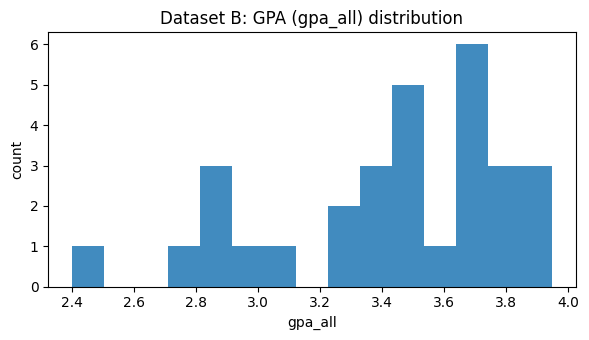

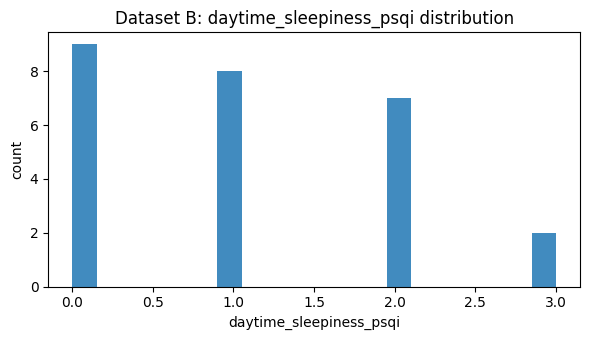

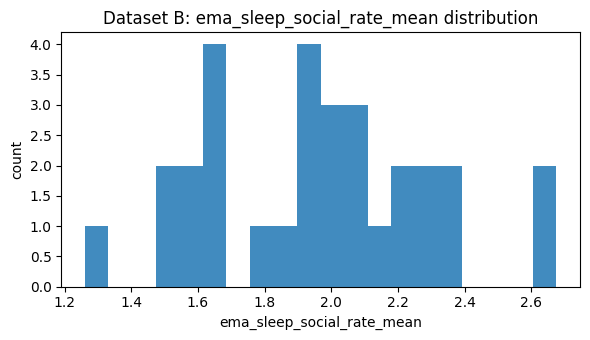

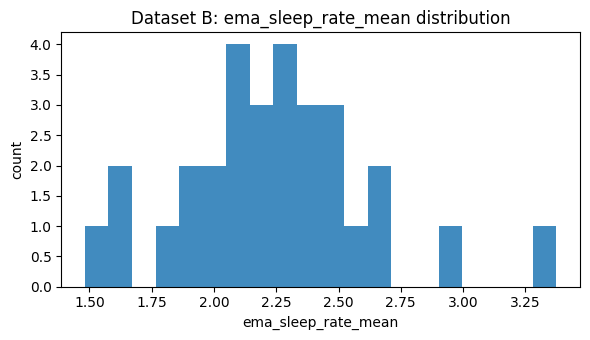

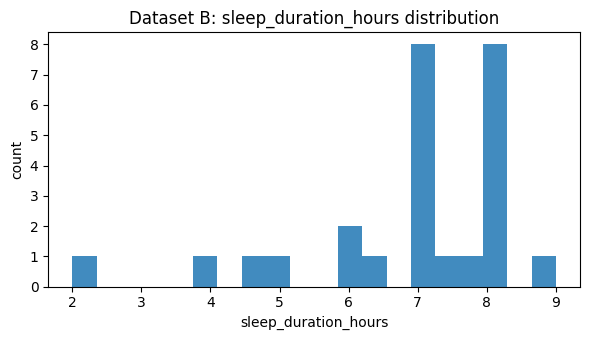

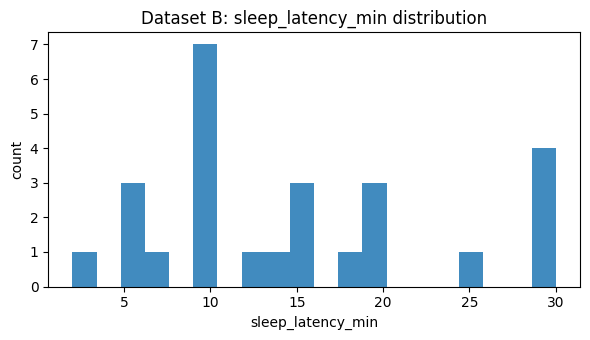

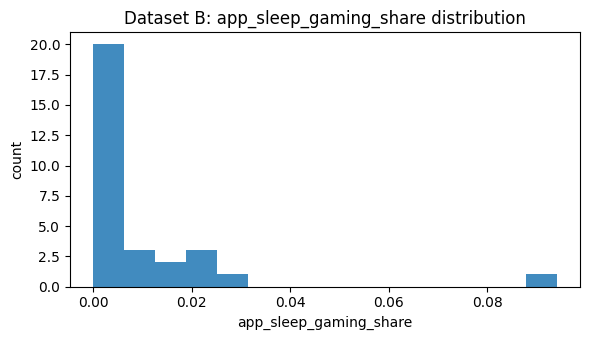

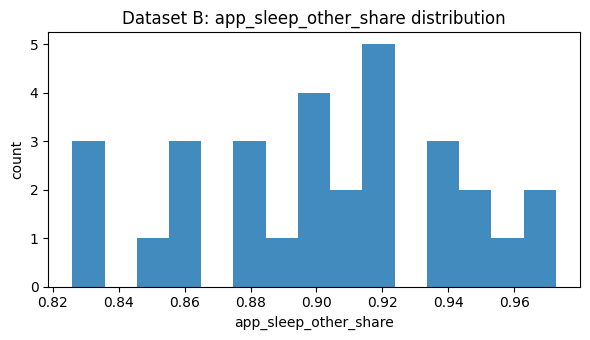

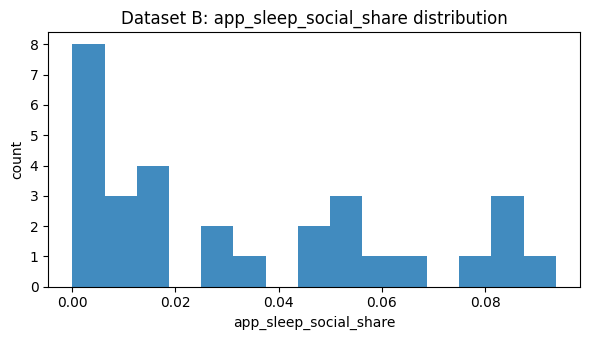

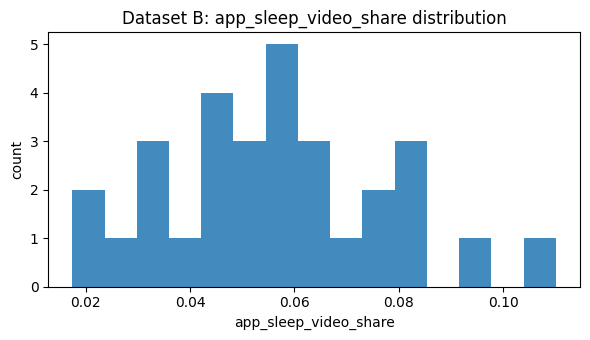

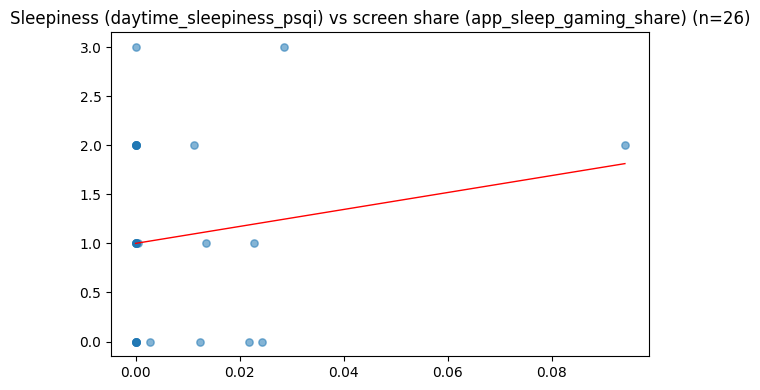

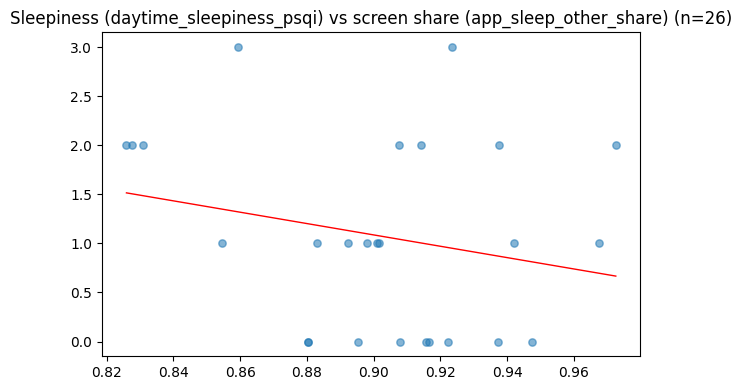

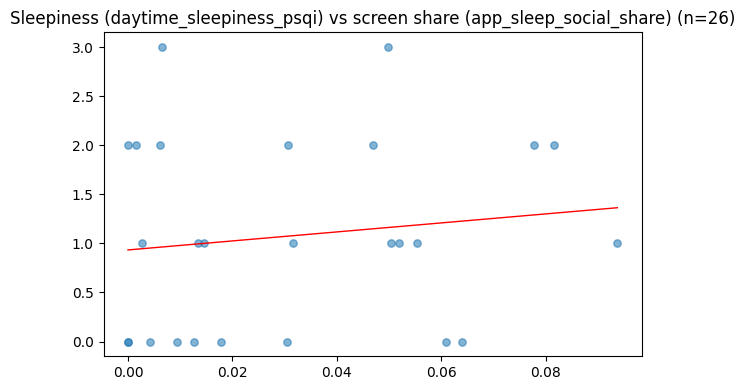

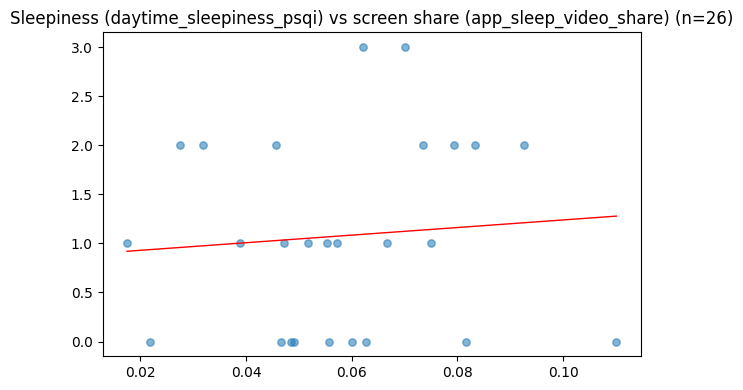

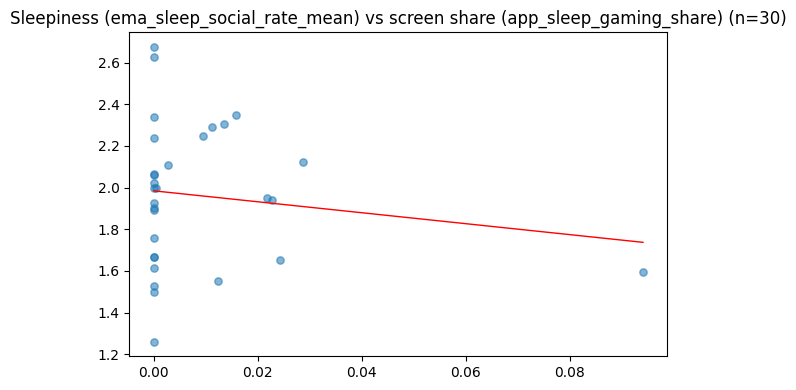

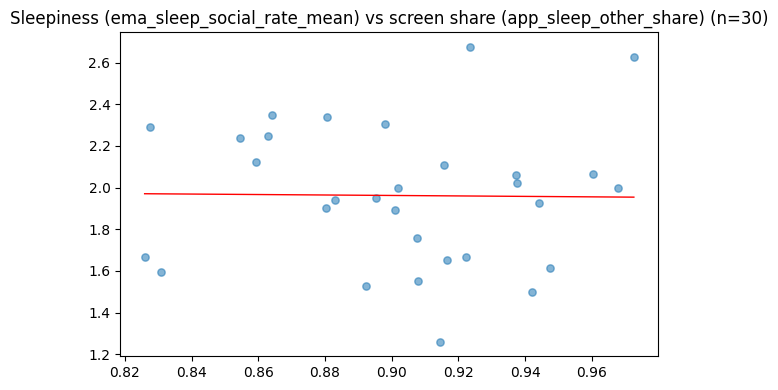

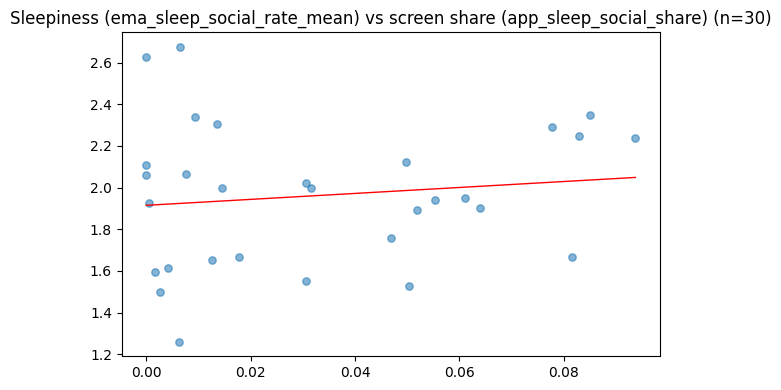

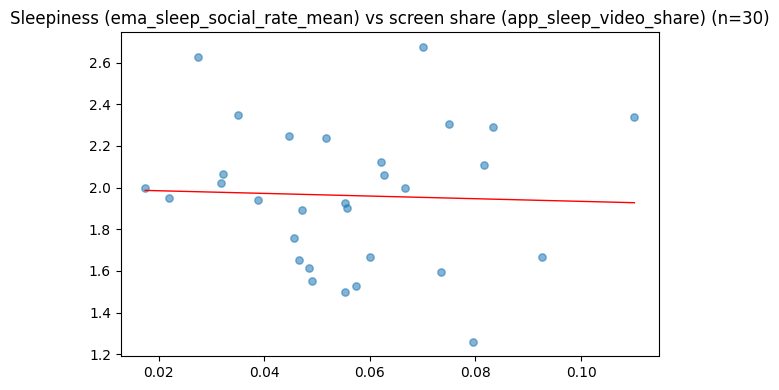

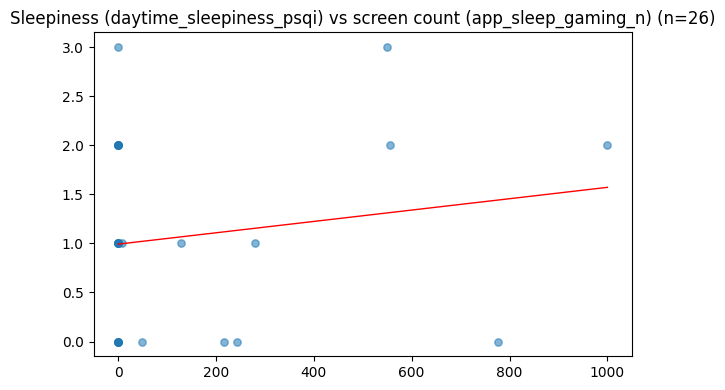

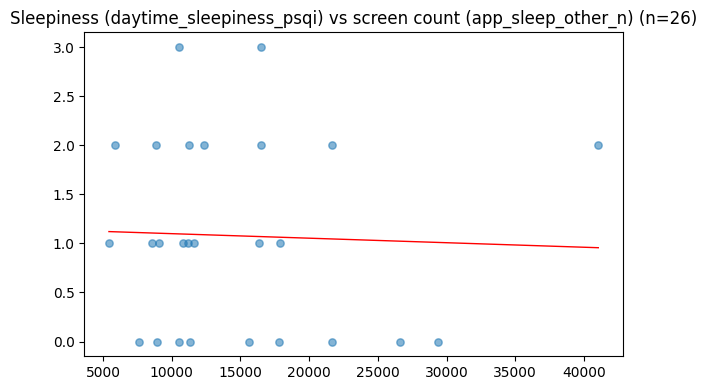

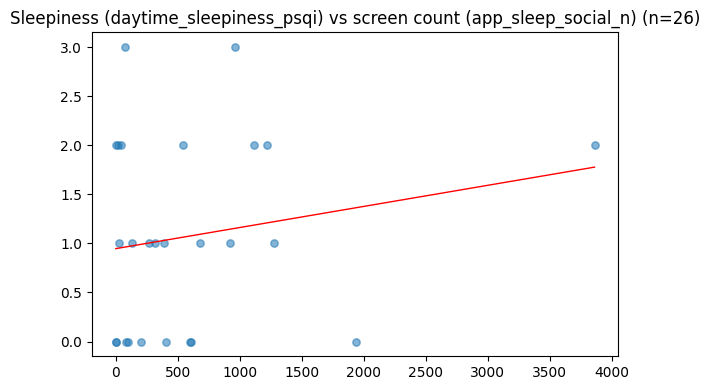

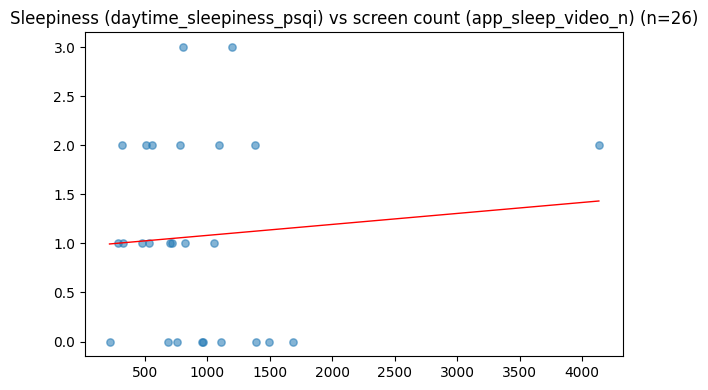

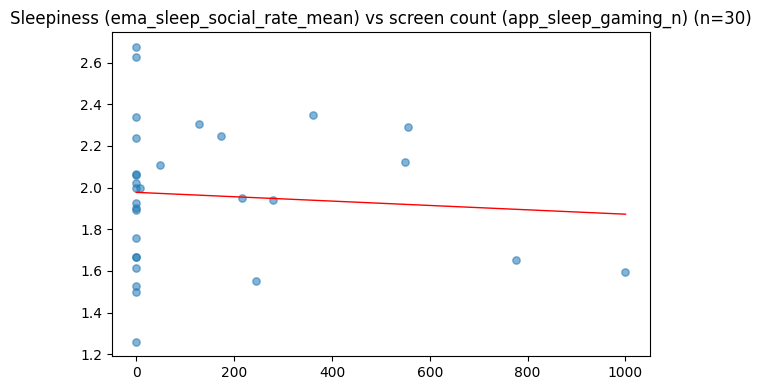

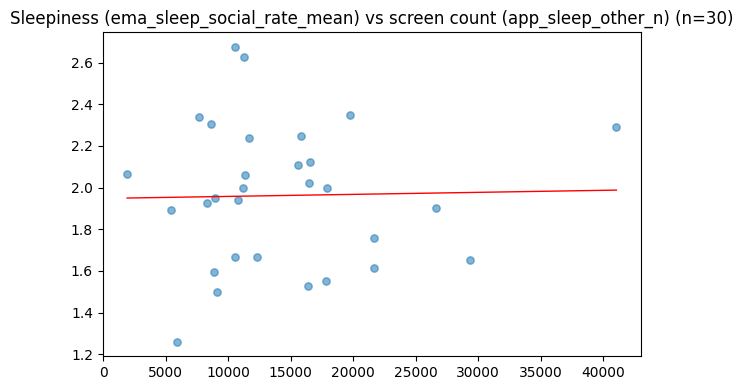

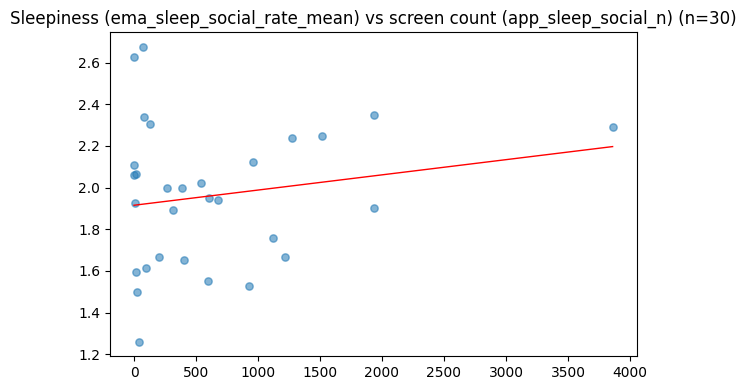

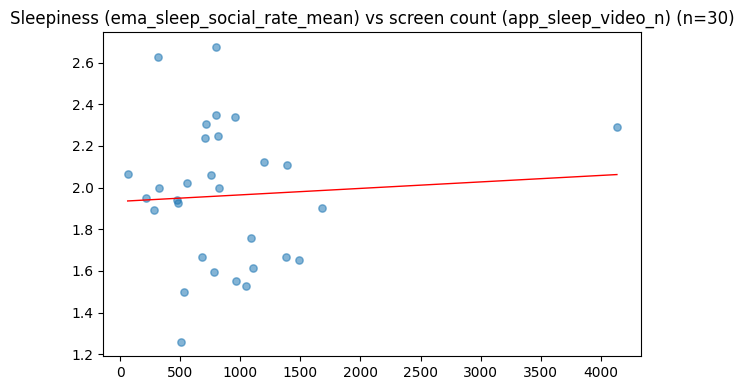

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional seaborn
try:
    import seaborn as sns  # type: ignore
    _HAS_SNS = True
except Exception:
    sns = None
    _HAS_SNS = False

# Guard
for req in ['B_model_df', 'B_feature_groups']:
    if req not in globals():
        raise RuntimeError(f"Missing `{req}`. Run Dataset B wrangling (B.2.1) first.")

Bv = B_model_df.copy()

# -----------------------
# 1) Basic distributions (outcome + key predictors)
# -----------------------

def _plot_hist(series: pd.Series, title: str, bins: int = 20):
    x = pd.to_numeric(series, errors='coerce').dropna()
    if x.shape[0] == 0:
        print(f"[skip] {title}: no non-missing values")
        return
    plt.figure(figsize=(6, 3.5))
    plt.hist(x, bins=bins, alpha=0.85)
    plt.title(title)
    plt.xlabel(series.name or '')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()

# Outcome
if 'gpa_all' in Bv.columns:
    _plot_hist(Bv['gpa_all'], 'Dataset B: GPA (gpa_all) distribution', bins=15)

# Sleepiness measures
for c in ['daytime_sleepiness_psqi', 'ema_sleep_social_rate_mean', 'ema_sleep_rate_mean', 'sleep_duration_hours', 'sleep_latency_min']:
    if c in Bv.columns:
        _plot_hist(Bv[c], f'Dataset B: {c} distribution')

# Screen category shares
screen_share_cols = [c for c in Bv.columns if c.startswith('app_sleep_') and c.endswith('_share')]
for c in sorted(screen_share_cols):
    _plot_hist(Bv[c], f'Dataset B: {c} distribution', bins=15)

# -----------------------
# 2) Sleepiness vs screen categories
# -----------------------

def _scatter_with_fit(df: pd.DataFrame, x: str, y: str, title: str):
    sub = df[[x, y]].copy()
    sub[x] = pd.to_numeric(sub[x], errors='coerce')
    sub[y] = pd.to_numeric(sub[y], errors='coerce')
    sub = sub.dropna()
    if sub.shape[0] < 10:
        print(f"[skip] {title}: n={sub.shape[0]} < 10")
        return

    plt.figure(figsize=(6, 4))
    if _HAS_SNS:
        sns.regplot(data=sub, x=x, y=y, scatter_kws={'alpha': 0.55, 's': 28}, line_kws={'color': 'red'})
    else:
        plt.scatter(sub[x], sub[y], alpha=0.55, s=28)
        # simple linear fit
        try:
            b1, b0 = np.polyfit(sub[x].values, sub[y].values, 1)
            xs = np.linspace(sub[x].min(), sub[x].max(), 100)
            plt.plot(xs, b1 * xs + b0, color='red', linewidth=1)
        except Exception:
            pass
    plt.title(f"{title} (n={sub.shape[0]})")
    plt.tight_layout()
    plt.show()

sleepiness_targets = [c for c in ['daytime_sleepiness_psqi', 'ema_sleep_social_rate_mean'] if c in Bv.columns]
if len(sleepiness_targets) == 0:
    print('No sleepiness targets found for plotting (expected daytime_sleepiness_psqi and/or ema_sleep_social_rate_mean).')

for y in sleepiness_targets:
    for x in sorted(screen_share_cols):
        _scatter_with_fit(Bv, x=x, y=y, title=f'Sleepiness ({y}) vs screen share ({x})')

# Optional: screen category counts vs sleepiness
screen_count_cols = [c for c in Bv.columns if re.match(r'^app_sleep_(social|gaming|video|other)_n$', c or '')]
for y in sleepiness_targets:
    for x in sorted(screen_count_cols):
        _scatter_with_fit(Bv, x=x, y=y, title=f'Sleepiness ({y}) vs screen count ({x})')


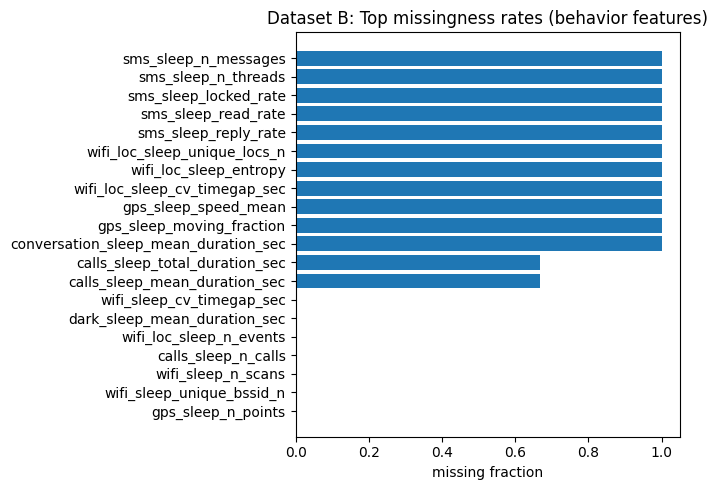

Behavior feature summary (selected stats):
                               count           mean           std           min            5%            50%            95%            max
sms_sleep_n_messages             0.0            NaN           NaN           NaN           NaN            NaN            NaN            NaN
sms_sleep_n_threads              0.0            NaN           NaN           NaN           NaN            NaN            NaN            NaN
sms_sleep_locked_rate            0.0            NaN           NaN           NaN           NaN            NaN            NaN            NaN
sms_sleep_read_rate              0.0            NaN           NaN           NaN           NaN            NaN            NaN            NaN
sms_sleep_reply_rate             0.0            NaN           NaN           NaN           NaN            NaN            NaN            NaN
wifi_loc_sleep_n_events         30.0       0.000000      0.000000      0.000000      0.000000       0.000000       0.000000

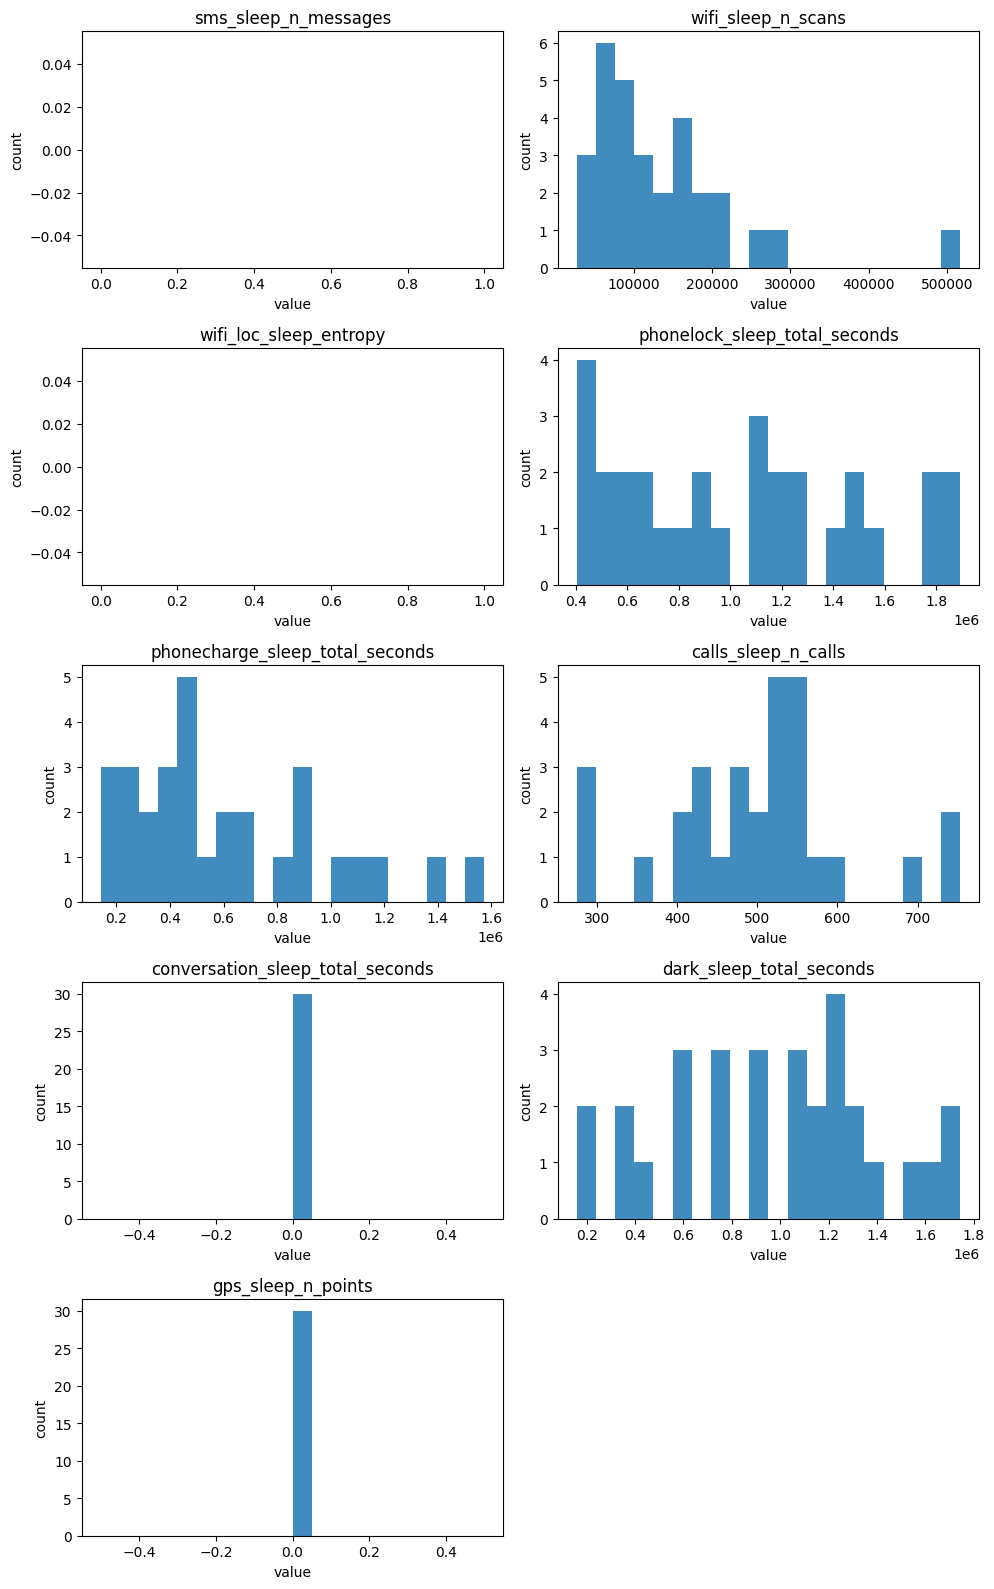

Correlation matrix (selected behavior proxies):
                                  sms_sleep_n_messages  wifi_sleep_n_scans  wifi_loc_sleep_entropy  phonelock_sleep_total_seconds  phonecharge_sleep_total_seconds  calls_sleep_n_calls  conversation_sleep_total_seconds  dark_sleep_total_seconds  gps_sleep_n_points
sms_sleep_n_messages                               NaN                 NaN                     NaN                            NaN                              NaN                  NaN                               NaN                       NaN                 NaN
wifi_sleep_n_scans                                 NaN                1.00                     NaN                           0.29                             0.27                 0.46                               NaN                      0.20                 NaN
wifi_loc_sleep_entropy                             NaN                 NaN                     NaN                            NaN                              N

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns  # type: ignore
    _HAS_SNS = True
except Exception:
    sns = None
    _HAS_SNS = False

# Guard
if 'B_model_df' not in globals() or 'B_feature_groups' not in globals():
    raise RuntimeError('Missing B_model_df / B_feature_groups. Run B.2.1 first.')

Bv = B_model_df.copy()

behavior_cols = B_feature_groups.get('behavior_only', [])
if len(behavior_cols) == 0:
    print('No behavior_only features found. (Did B.2 feature engineering run and merge into B_cohort_df?)')
else:
    # -----------------------
    # 3) Missingness and range sanity checks
    # -----------------------
    miss = Bv[behavior_cols].isna().mean().sort_values(ascending=False)
    plt.figure(figsize=(7, 5))
    plt.barh(miss.head(20).index[::-1], miss.head(20).values[::-1])
    plt.title('Dataset B: Top missingness rates (behavior features)')
    plt.xlabel('missing fraction')
    plt.tight_layout()
    plt.show()

    # Show a quick numeric summary for a handful of features
    summary = Bv[behavior_cols].apply(pd.to_numeric, errors='coerce').describe(percentiles=[0.05, 0.5, 0.95]).T
    display_cols = [c for c in ['count', 'mean', 'std', 'min', '5%', '50%', '95%', 'max'] if c in summary.columns]
    print('Behavior feature summary (selected stats):')
    print(summary[display_cols].head(15).to_string())

    # -----------------------
    # 4) Distributions for a few common-sense engineered proxies
    # -----------------------
    preferred = [
        'sms_sleep_n_messages',
        'wifi_sleep_n_scans',
        'wifi_loc_sleep_entropy',
        'phonelock_sleep_total_seconds',
        'phonecharge_sleep_total_seconds',
        'calls_sleep_n_calls',
        'conversation_sleep_total_seconds',
        'dark_sleep_total_seconds',
        'gps_sleep_n_points',
    ]
    to_plot = [c for c in preferred if c in Bv.columns]

    if len(to_plot) == 0:
        # fallback: pick up to 8 least-missing behavior features
        to_plot = [c for c in miss.index if c in behavior_cols][:8]

    n = len(to_plot)
    if n > 0:
        ncols = 2
        nrows = int(np.ceil(n / ncols))
        plt.figure(figsize=(10, 3.2 * nrows))
        for i, c in enumerate(to_plot, 1):
            x = pd.to_numeric(Bv[c], errors='coerce').dropna()
            plt.subplot(nrows, ncols, i)
            plt.hist(x, bins=20, alpha=0.85)
            plt.title(c)
            plt.xlabel('value')
            plt.ylabel('count')
        plt.tight_layout()
        plt.show()

    # -----------------------
    # 5) Simple correlation view (sanity check)
    # -----------------------
    corr_cols = [c for c in to_plot if c in Bv.columns]
    if len(corr_cols) >= 3:
        data = Bv[corr_cols].apply(pd.to_numeric, errors='coerce')
        corr = data.corr()
        if _HAS_SNS:
            plt.figure(figsize=(6.5, 5.5))
            sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
            plt.title('Dataset B: Correlations (selected behavior proxies)')
            plt.tight_layout()
            plt.show()
        else:
            print('Correlation matrix (selected behavior proxies):')
            print(corr.round(2).to_string())


## B.4 Mediation-style inference (Dataset B): screen → sleepiness/sleep → GPA

We mirror the Dataset A workflow using linear regression in three steps:

- **Mediator model**: \(M \sim X + \text{Cov}\)
- **Outcome model**: \(Y \sim X + M + \text{Cov}\)
- **Total effect model**: \(Y \sim X + \text{Cov}\)

Where:
- \(Y\) is **`gpa_all`** (primary outcome).
- \(X\) is a **screen exposure composite** built from the app-derived screen-category features (by default, shares if present).
- \(M\) is one sleep construct at a time (PSQI sleepiness or sleep duration; EMA sleepiness if available).

Uncertainty + diagnostics:
- **Bootstrap** CIs for \(a\), \(b\), \(c'\), \(c\), and indirect effect \(a\times b\).
- **Permutation null** for the indirect effect magnitude.
- **VIF** on the outcome-model design matrix and residual diagnostic plots (residuals vs fitted + Q-Q plots).

Interpretation note:
- This is **mediation-style evidence** in cross-sectional data; treat it as an association workflow rather than definitive causal mediation.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels is preferred; if unavailable, fall back to a lightweight numpy-based OLS
try:
    import statsmodels.api as sm  # type: ignore
    _HAS_SM = True
except Exception:
    _HAS_SM = False

    def _add_constant(X: pd.DataFrame) -> np.ndarray:
        X_arr = np.asarray(X, dtype=float)
        ones = np.ones((X_arr.shape[0], 1), dtype=float)
        return np.hstack([ones, X_arr])

    class _OLSResult:
        def __init__(self, y: np.ndarray, X: np.ndarray, beta: np.ndarray):
            self.params = beta
            self.fittedvalues = X @ beta
            self.resid = y - self.fittedvalues

    class _OLS:
        def __init__(self, y: np.ndarray, X: np.ndarray):
            self.y = np.asarray(y, dtype=float)
            self.X = np.asarray(X, dtype=float)

        def fit(self):
            beta, *_ = np.linalg.lstsq(self.X, self.y, rcond=None)
            return _OLSResult(self.y, self.X, beta)

# -----------------------
# Config
# -----------------------
SEED = globals().get('SEED', 42)
N_BOOT = int(globals().get('N_BOOT', 1000))
N_PERM = int(globals().get('N_PERM', 300))

# Guard
for req in ['B_model_df', 'B_feature_groups']:
    if req not in globals():
        raise RuntimeError(f"Missing `{req}`. Run B.2.1 wrangling first.")

Y_COL = 'gpa_all'
BASE_DF = B_model_df.copy()
if Y_COL not in BASE_DF.columns:
    raise RuntimeError(f"Missing outcome '{Y_COL}' in B_model_df")

# -----------------------
# Define X (screen exposure composite)
# -----------------------
screen_features_all = [c for c in B_feature_groups.get('screen_only', []) if c in BASE_DF.columns]
screen_share_cols = [c for c in screen_features_all if c.startswith('app_sleep_') and c.endswith('_share')]

# Prefer shares (scale-consistent); fall back to all screen features
screen_features = screen_share_cols if len(screen_share_cols) > 0 else screen_features_all
if len(screen_features) == 0:
    raise RuntimeError('No screen features found for Dataset B mediation. Ensure app_usage features were engineered and merged.')

BASE_DF['screen_exposure_raw'] = BASE_DF[screen_features].fillna(0).sum(axis=1)

# Optional covariates: keep minimal here; include other sleep construct to interpret M separately
COV_BASE: list[str] = []

# Mediators to run (if present)
MEDIATOR_SPECS: list[tuple[str, str | None]] = [
    ('daytime_sleepiness_psqi', 'sleep_duration_hours'),
    ('sleep_duration_hours', 'daytime_sleepiness_psqi'),
]
if 'ema_sleep_social_rate_mean' in BASE_DF.columns:
    MEDIATOR_SPECS.append(('ema_sleep_social_rate_mean', 'sleep_duration_hours'))


def _standardize_1sd(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors='coerce')
    sd = x.std(ddof=0)
    if sd is None or sd == 0 or np.isnan(sd):
        return x * 0.0
    return (x - x.mean()) / sd


def _fit_ols_models(df_work: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    df_work = df_work.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()
    df_work['X_std'] = _standardize_1sd(df_work['screen_exposure_raw'])

    y = df_work[Y_COL].astype(float).values
    m = df_work[mediator_col].astype(float).values

    # M ~ X + Cov
    X_m = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_work[c].values
    if _HAS_SM:
        X_m_sm = sm.add_constant(X_m, has_constant='add')
        model_m = sm.OLS(m, X_m_sm).fit()
        a = float(model_m.params['x'])
    else:
        model_m = _OLS(m, _add_constant(X_m)).fit()
        a = float(model_m.params[1])

    # Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_work['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_work[c].values
    if _HAS_SM:
        X_y_sm = sm.add_constant(X_y, has_constant='add')
        model_y = sm.OLS(y, X_y_sm).fit()
        b = float(model_y.params['m'])
        c_prime = float(model_y.params['x'])
    else:
        model_y = _OLS(y, _add_constant(X_y)).fit()
        # params: [const, x, m, cov...]
        b = float(model_y.params[2])
        c_prime = float(model_y.params[1])

    # Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_work[c].values
    if _HAS_SM:
        X_t_sm = sm.add_constant(X_t, has_constant='add')
        model_t = sm.OLS(y, X_t_sm).fit()
        c_total = float(model_t.params['x'])
    else:
        model_t = _OLS(y, _add_constant(X_t)).fit()
        c_total = float(model_t.params[1])

    indirect = a * b

    return {
        'n': int(df_work.shape[0]),
        'a': a,
        'b': b,
        'c_prime': c_prime,
        'c_total': c_total,
        'indirect': indirect,
        'model_m': model_m,
        'model_y': model_y,
        'model_t': model_t,
        'df_work': df_work,
    }


def _vif(df_design: pd.DataFrame) -> pd.Series:
    from numpy.linalg import LinAlgError

    vifs = {}
    for col in df_design.columns:
        y = df_design[col].astype(float).values
        X = df_design.drop(columns=[col]).astype(float)
        if X.shape[1] == 0:
            vifs[col] = np.nan
            continue
        try:
            r2 = sm.OLS(y, sm.add_constant(X, has_constant='add')).fit().rsquared
            vifs[col] = float(1.0 / (1.0 - r2)) if (1.0 - r2) != 0 else np.inf
        except LinAlgError:
            vifs[col] = np.inf
    return pd.Series(vifs)


def _compute_effects(df_sample: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    df_sample = df_sample.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()
    if df_sample.shape[0] < 30:
        return None

    df_sample['X_std'] = _standardize_1sd(df_sample['screen_exposure_raw'])

    y = df_sample[Y_COL].astype(float).values
    m = df_sample[mediator_col].astype(float).values

    X_m = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_sample[c].values
    if _HAS_SM:
        X_m_sm = sm.add_constant(X_m, has_constant='add')
        model_m = sm.OLS(m, X_m_sm).fit()
        a = float(model_m.params['x'])
    else:
        model_m = _OLS(m, _add_constant(X_m)).fit()
        a = float(model_m.params[1])

    X_y = pd.DataFrame({'x': df_sample['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_sample[c].values
    if _HAS_SM:
        X_y_sm = sm.add_constant(X_y, has_constant='add')
        model_y = sm.OLS(y, X_y_sm).fit()
        b = float(model_y.params['m'])
        c_prime = float(model_y.params['x'])
    else:
        model_y = _OLS(y, _add_constant(X_y)).fit()
        b = float(model_y.params[2])
        c_prime = float(model_y.params[1])

    X_t = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_sample[c].values
    if _HAS_SM:
        X_t_sm = sm.add_constant(X_t, has_constant='add')
        model_t = sm.OLS(y, X_t_sm).fit()
        c_total = float(model_t.params['x'])
    else:
        model_t = _OLS(y, _add_constant(X_t)).fit()
        c_total = float(model_t.params[1])

    indirect = a * b
    return a, b, c_prime, c_total, indirect


def _ci(x: np.ndarray, alpha: float = 0.05):
    lo = np.nanpercentile(x, 100 * (alpha / 2))
    hi = np.nanpercentile(x, 100 * (1 - alpha / 2))
    return float(lo), float(hi)


rng = np.random.default_rng(SEED)
results_rows = []

for mediator_col, other_sleep_cov in MEDIATOR_SPECS:
    if mediator_col not in BASE_DF.columns:
        print(f"Skipping mediator '{mediator_col}': missing column")
        continue

    cov_cols = list(COV_BASE)
    if other_sleep_cov is not None and other_sleep_cov in BASE_DF.columns and other_sleep_cov != mediator_col:
        cov_cols = cov_cols + [other_sleep_cov]

    base_df = BASE_DF[[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols].dropna().copy()
    n = int(base_df.shape[0])
    if n < 80:
        print(f"WARNING: mediation run for mediator='{mediator_col}' has small n={n} complete cases.")

    observed = _fit_ols_models(base_df, mediator_col=mediator_col, cov_cols=cov_cols)

    # VIF on outcome-model predictors
    dfv = observed['df_work'].copy()
    dfv['X_std'] = _standardize_1sd(dfv['screen_exposure_raw'])
    design_out = pd.DataFrame({'X_std': dfv['X_std'].values, 'M': dfv[mediator_col].astype(float).values})
    for c in cov_cols:
        design_out[c] = dfv[c].values
    vif = _vif(design_out)

    print("\n" + "=" * 80)
    print(f"Dataset B mediation run: M='{mediator_col}', Cov={cov_cols}")
    print(f"Complete-case n={observed['n']}")
    print(f"Path estimates: a (X->M)={observed['a']:.4f}, b (M->Y|X)={observed['b']:.4f}")
    print(f"Effects: indirect=a*b={observed['indirect']:.4f}, direct c'={observed['c_prime']:.4f}, total c={observed['c_total']:.4f}")
    print("VIF (outcome model predictors):")
    print(vif.sort_values(ascending=False).to_string())

    # Bootstrap
    boot_effects = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        sample_df = base_df.iloc[idx]
        eff = _compute_effects(sample_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        boot_effects.append(eff)

    boot_effects = np.array(boot_effects, dtype=float)

    # Normalize bootstrap output shape to (n_draws, 5).
    # With small n, numpy can sometimes produce a 1D array.
    if boot_effects.ndim == 1:
        if boot_effects.size == 0:
            boot_effects = boot_effects.reshape(0, 5)
        elif boot_effects.size == 5:
            boot_effects = boot_effects.reshape(1, 5)
        else:
            boot_effects = boot_effects.reshape(0, 5)

    if boot_effects.ndim == 2 and boot_effects.shape[1] != 5:
        boot_effects = boot_effects.reshape(0, 5)

    if boot_effects.shape[0] < max(50, int(N_BOOT * 0.5)):
        print(f"WARNING: bootstrap draws succeeded={boot_effects.shape[0]} / {N_BOOT} for mediator='{mediator_col}'")

    if boot_effects.shape[0] == 0:
        a_ci = (np.nan, np.nan)
        b_ci = (np.nan, np.nan)
        c_prime_ci = (np.nan, np.nan)
        c_total_ci = (np.nan, np.nan)
        indirect_ci = (np.nan, np.nan)
    else:
        a_ci = _ci(boot_effects[:, 0])
        b_ci = _ci(boot_effects[:, 1])
        c_prime_ci = _ci(boot_effects[:, 2])
        c_total_ci = _ci(boot_effects[:, 3])
        indirect_ci = _ci(boot_effects[:, 4])

    # Permutation null for indirect
    perm_indirect = []
    x_values = base_df['screen_exposure_raw'].astype(float).values
    for _ in range(N_PERM):
        perm_df = base_df.copy()
        perm_df['screen_exposure_raw'] = rng.permutation(x_values)
        eff = _compute_effects(perm_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        perm_indirect.append(eff[-1])

    perm_indirect = np.array(perm_indirect, dtype=float)
    if perm_indirect.size == 0:
        p_perm = np.nan
    else:
        p_perm = (np.sum(np.abs(perm_indirect) >= abs(observed['indirect'])) + 1) / (len(perm_indirect) + 1)

    results_rows.append({
        'mediator': mediator_col,
        'n_complete_cases': observed['n'],
        'a_hat': observed['a'],
        'a_ci_low': a_ci[0],
        'a_ci_high': a_ci[1],
        'b_hat': observed['b'],
        'b_ci_low': b_ci[0],
        'b_ci_high': b_ci[1],
        'c_prime_hat': observed['c_prime'],
        'c_prime_ci_low': c_prime_ci[0],
        'c_prime_ci_high': c_prime_ci[1],
        'c_total_hat': observed['c_total'],
        'c_total_ci_low': c_total_ci[0],
        'c_total_ci_high': c_total_ci[1],
        'indirect_hat': observed['indirect'],
        'indirect_ci_low': indirect_ci[0],
        'indirect_ci_high': indirect_ci[1],
        'perm_p_value': float(p_perm),
        'boot_succ': int(boot_effects.shape[0]),
        'perm_succ': int(perm_indirect.shape[0]),
        'x_composite_cols': ','.join(screen_features),
        'covariates_in_models': ','.join(cov_cols),
    })

    # Diagnostics plots
    model_m = observed['model_m']
    model_y = observed['model_y']

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].scatter(model_m.fittedvalues, model_m.resid, alpha=0.35)
    axes[0, 0].axhline(0, color='red', linewidth=1)
    axes[0, 0].set_title(f"Mediator residuals vs fitted\nM={mediator_col}")
    axes[0, 0].set_xlabel('Fitted')
    axes[0, 0].set_ylabel('Residuals')

    axes[0, 1].scatter(model_y.fittedvalues, model_y.resid, alpha=0.35)
    axes[0, 1].axhline(0, color='red', linewidth=1)
    axes[0, 1].set_title(f"Outcome residuals vs fitted\nY={Y_COL}")
    axes[0, 1].set_xlabel('Fitted')
    axes[0, 1].set_ylabel('Residuals')

    if _HAS_SM:
        sm.qqplot(model_m.resid, line='45', ax=axes[1, 0])
        axes[1, 0].set_title(f"Q-Q plot (mediator residuals)\nM={mediator_col}")

        sm.qqplot(model_y.resid, line='45', ax=axes[1, 1])
        axes[1, 1].set_title("Q-Q plot (outcome residuals)")
    else:
        axes[1, 0].axis('off')
        axes[1, 1].axis('off')
        axes[1, 0].text(0.0, 0.5, 'Q-Q plots require statsmodels', fontsize=10)

    plt.tight_layout()
    plt.show()

B_mediation_results = pd.DataFrame(results_rows).sort_values('mediator')

print("\n" + "=" * 80)
print("Dataset B mediation summary (screen -> sleep -> GPA)")
print(B_mediation_results.to_string(index=False))

# Keep for later cross-cohort comparison
B_mediation_results_df = B_mediation_results


TypeError: _OLSResult.__init__() got an unexpected keyword argument 'params'

## B.5 Prediction & Feature-Group Ablations (RQ3) (Dataset B)

This section runs supervised prediction on `gpa_all` using feature-group ablations:
- `screen_only`
- `sleep_only`
- `behavior_only` (sensed proxies)
- `combined`

We use cross-validation with median imputation, compare `RMSE` / `R^2` across model families, and compute permutation importance (and coefficient magnitude when available) for the best combined model.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

SEED = 42
N_SPLITS = 5

# Guards
if 'B_model_df' not in globals():
    raise RuntimeError("Missing `B_model_df`. Run Dataset B wrangling (B.2.1) first.")
if 'B_feature_groups' not in globals():
    raise RuntimeError("Missing `B_feature_groups`. Run Dataset B wrangling (B.2.1) first.")

# Target
if 'B_PRIMARY_OUTCOME_COL' in globals():
    Y_COL = B_PRIMARY_OUTCOME_COL
else:
    Y_COL = 'gpa_all'

if Y_COL not in B_model_df.columns:
    raise RuntimeError(f"Missing target '{Y_COL}' in B_model_df")

# Modeling frame
df_ml = B_model_df.copy()
df_ml[Y_COL] = pd.to_numeric(df_ml[Y_COL], errors='coerce')
df_ml = df_ml.dropna(subset=[Y_COL]).copy()

# Feature groups (limit to columns present)
feature_groups = {}
for grp, cols in B_feature_groups.items():
    cols2 = [c for c in cols if c in df_ml.columns and c != 'uid']
    if len(cols2) > 0:
        feature_groups[grp] = cols2

for required in ['screen_only', 'sleep_only', 'behavior_only', 'combined']:
    if required not in feature_groups:
        print(f"WARNING: feature group '{required}' missing or empty")

if 'combined' not in feature_groups or len(feature_groups['combined']) == 0:
    raise RuntimeError("No features available for 'combined' ablation group.")

# CV folds (shared across ablations for fair comparison)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(kf.split(df_ml))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_group(group_name: str, cols: list[str]):
    X = df_ml[cols]
    y = df_ml[Y_COL].astype(float).values

    # Model families
    ridge_alphas = np.logspace(-2, 2, 9)       # 0.01 ... 100
    elastic_alphas = np.logspace(-3, 0, 7)    # 0.001 ... 1
    elastic_l1_ratios = [0.1, 0.5, 0.9]

    def make_dummy():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', DummyRegressor(strategy='mean')),
        ])

    def make_ols():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', LinearRegression()),
        ])

    def make_ridge():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', RidgeCV(alphas=ridge_alphas, cv=5)),
        ])

    def make_elastic():
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', ElasticNetCV(
                alphas=elastic_alphas,
                l1_ratio=elastic_l1_ratios,
                cv=5,
                max_iter=100000,
                random_state=SEED,
            )),
        ])

    model_builders = {
        'baseline_mean': make_dummy,
        'ols': make_ols,
        'ridge_ridgecv': make_ridge,
        'elastic_elasticnetcv': make_elastic,
    }

    results = []

    # Store out-of-fold predictions for later interpretability/plots
    oof_preds_by_model = {name: np.full_like(y, fill_value=np.nan, dtype=float) for name in model_builders}

    for model_name, make_model in model_builders.items():
        fold_rmses, fold_maes, fold_r2s = [], [], []

        for fold_i, (train_idx, test_idx) in enumerate(folds):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = make_model()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            oof_preds_by_model[model_name][test_idx] = y_pred

            fold_rmses.append(rmse(y_test, y_pred))
            fold_maes.append(float(mean_absolute_error(y_test, y_pred)))
            fold_r2s.append(float(r2_score(y_test, y_pred)))

        results.append({
            'feature_group': group_name,
            'model': model_name,
            'n_features': int(len(cols)),
            'rmse_mean': float(np.mean(fold_rmses)),
            'rmse_std': float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0,
            'mae_mean': float(np.mean(fold_maes)),
            'r2_mean': float(np.mean(fold_r2s)),
            'r2_std': float(np.std(fold_r2s, ddof=1)) if len(fold_r2s) > 1 else 0.0,
        })

    results_df = pd.DataFrame(results).sort_values('r2_mean', ascending=False)
    return results_df, oof_preds_by_model, X, y


all_rows = []
oof_predictions_store = {}
X_store = {}
y_store = {}

for group_name, cols in feature_groups.items():
    if len(cols) == 0:
        continue

    print(f"\nEvaluating feature group: {group_name} (n_features={len(cols)})")
    res_df, oof_preds_by_model, X, y = evaluate_group(group_name, cols)
    print(res_df[['model', 'r2_mean', 'rmse_mean']].to_string(index=False))

    all_rows.append(res_df)
    oof_predictions_store[group_name] = oof_preds_by_model
    X_store[group_name] = X
    y_store[group_name] = y

B_ml_cv_summary = pd.concat(all_rows, ignore_index=True)
B_ml_cv_summary = B_ml_cv_summary.sort_values(['feature_group', 'r2_mean'], ascending=[True, False])

print("\n" + "=" * 80)
print("Dataset B supervised prediction summary (CV)")
print(B_ml_cv_summary.to_string(index=False))

# Choose best model for interpretability from the combined group
combined_summary = B_ml_cv_summary[B_ml_cv_summary['feature_group'] == 'combined']
regularized = combined_summary[combined_summary['model'].isin(['ridge_ridgecv', 'elastic_elasticnetcv'])]

if len(regularized) > 0:
    best_model_name = regularized.sort_values('r2_mean', ascending=False).iloc[0]['model']
else:
    best_model_name = combined_summary.sort_values('r2_mean', ascending=False).iloc[0]['model']

print(f"\nBest combined model for interpretability: {best_model_name}")

# OOF predictions plot for the chosen best model
X_comb = X_store['combined']
y_comb = y_store['combined']
oof_pred_comb = oof_predictions_store['combined'][best_model_name]

B_ml_oof_predictions = pd.DataFrame({
    'y_true': y_comb,
    'y_pred': oof_pred_comb,
})

plt.figure(figsize=(6, 5))
plt.scatter(B_ml_oof_predictions['y_true'], B_ml_oof_predictions['y_pred'], alpha=0.5)
minv = float(min(B_ml_oof_predictions['y_true'].min(), B_ml_oof_predictions['y_pred'].min()))
maxv = float(max(B_ml_oof_predictions['y_true'].max(), B_ml_oof_predictions['y_pred'].max()))
plt.plot([minv, maxv], [minv, maxv], color='red', linewidth=1)
plt.xlabel(f'True {Y_COL}')
plt.ylabel(f'Predicted {Y_COL} (OOF)')
plt.title(f"Combined features: {best_model_name} (OOF)")
plt.tight_layout()
plt.show()

# Fit best model on full combined dataset for coefficient/permutation importance
cols_comb = feature_groups['combined']
X_full = X_comb
y_full = y_comb

ridge_alphas = np.logspace(-2, 2, 9)
elastic_alphas = np.logspace(-3, 0, 7)
elastic_l1_ratios = [0.1, 0.5, 0.9]

if best_model_name == 'ridge_ridgecv':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=ridge_alphas, cv=5)),
    ])
elif best_model_name == 'elastic_elasticnetcv':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', ElasticNetCV(
            alphas=elastic_alphas,
            l1_ratio=elastic_l1_ratios,
            cv=5,
            max_iter=100000,
            random_state=SEED,
        )),
    ])
else:
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LinearRegression()),
    ])

final_model.fit(X_full, y_full)

# Coefficient-based feature ranking (for linear regularized models)
coef_importance_df = None
if hasattr(final_model.named_steps['model'], 'coef_'):
    coefs = final_model.named_steps['model'].coef_
    coef_importance_df = pd.DataFrame({
        'feature': cols_comb,
        'coef': coefs,
        'abs_coef': np.abs(coefs),
    }).sort_values('abs_coef', ascending=False)

# Permutation importance (agnostic)
perm_importance_df = None
try:
    perm = permutation_importance(
        final_model,
        X_full,
        y_full,
        n_repeats=15,
        random_state=SEED,
        scoring='r2',
    )
    perm_importance_df = pd.DataFrame({
        'feature': cols_comb,
        'perm_importance_mean': perm.importances_mean,
        'perm_importance_std': perm.importances_std,
    }).sort_values('perm_importance_mean', ascending=False)
except Exception as e:
    print("Permutation importance failed:", repr(e))

if coef_importance_df is not None and perm_importance_df is not None:
    B_ml_feature_importance = coef_importance_df.merge(perm_importance_df, on='feature', how='left')
elif coef_importance_df is not None:
    B_ml_feature_importance = coef_importance_df
elif perm_importance_df is not None:
    B_ml_feature_importance = perm_importance_df
else:
    B_ml_feature_importance = pd.DataFrame({'feature': cols_comb})

B_ml_feature_importance = B_ml_feature_importance.reset_index(drop=True)

print("\nTop feature importance (combined):")
print(B_ml_feature_importance.head(15).to_string(index=False))

# Plot: permutation importance (if available)
if 'perm_importance_mean' in B_ml_feature_importance.columns and len(B_ml_feature_importance) > 0:
    topk = B_ml_feature_importance.head(15)
    plt.figure(figsize=(8, 5))
    plt.barh(topk['feature'][::-1], topk['perm_importance_mean'][::-1])
    plt.xlabel('Permutation importance (mean R^2 decrease)')
    plt.title('Top permutation-important features (combined)')
    plt.tight_layout()
    plt.show()

print("\nHow to interpret Dataset B prediction + ablation results:")
print(f"- Higher r2_mean for 'combined' vs 'screen_only'/'sleep_only'/'behavior_only' suggests that multiple signal groups add predictive information.")
print("- Permutation importance indicates which features contribute most to out-of-sample predictive performance in the CV setup (not causal effects).")


## C. Cross-cohort comparison (RQ1–RQ3)

This compares Dataset A (adolescents) vs Dataset B (college students) **without row-level merging**:

- **Mediation-style evidence**: compare indirect effects via (i) sleepiness and (ii) sleep duration.
- **Prediction (RQ3)**: compare supervised predictive performance across feature-group ablations.

Notes:
- The mediation workflow is association-style in cross-sectional/self-report sensing.
- The prediction comparison is purely predictive (not causal).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Guards: required outputs
# -----------------------
required_globals = [
    'A_mediation_results_df',
    'B_mediation_results_df',
    'A_ml_cv_summary',
    'B_ml_cv_summary',
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Missing required notebook outputs. Re-run cells for mediation/prediction first. Missing: "
        + ', '.join(missing)
    )

A_med = A_mediation_results_df.copy()
B_med = B_mediation_results_df.copy()

A_pred = A_ml_cv_summary.copy()
B_pred = B_ml_cv_summary.copy()

# -----------------------
# 1) Mediation comparison
# -----------------------
# Mediator name mapping (sleepiness construct differs by cohort)
mediation_pairs = {
    'sleepiness': {
        'A': 'sleepiness_pdss',
        'B': 'daytime_sleepiness_psqi',
    },
    'sleep_duration': {
        'A': 'sleep_duration_hours',
        'B': 'sleep_duration_hours',
    },
}


def _get_indirect(df: pd.DataFrame, mediator: str) -> pd.Series | None:
    rows = df[df['mediator'] == mediator]
    if rows.empty:
        return None
    # If duplicates exist, take the first (should not)
    return rows.iloc[0]


med_rows = []
for concept, pair in mediation_pairs.items():
    row = {
        'concept': concept,
        'A_mediator': pair['A'],
        'B_mediator': pair['B'],
    }

    a = _get_indirect(A_med, pair['A'])
    b = _get_indirect(B_med, pair['B'])

    if a is not None:
        row.update({
            'A_indirect_hat': float(a['indirect_hat']),
            'A_indirect_ci_low': float(a['indirect_ci_low']),
            'A_indirect_ci_high': float(a['indirect_ci_high']),
            'A_perm_p_value': float(a.get('perm_p_value', np.nan)),
            'A_n': int(a['n_complete_cases']) if 'n_complete_cases' in a else int(a.get('n_complete_cases', np.nan)),
        })
    else:
        row.update({
            'A_indirect_hat': np.nan,
            'A_indirect_ci_low': np.nan,
            'A_indirect_ci_high': np.nan,
            'A_perm_p_value': np.nan,
            'A_n': np.nan,
        })

    if b is not None:
        row.update({
            'B_indirect_hat': float(b['indirect_hat']),
            'B_indirect_ci_low': float(b['indirect_ci_low']),
            'B_indirect_ci_high': float(b['indirect_ci_high']),
            'B_perm_p_value': float(b.get('perm_p_value', np.nan)),
            'B_n': int(b['n_complete_cases']) if 'n_complete_cases' in b else int(b.get('n_complete_cases', np.nan)),
        })
    else:
        row.update({
            'B_indirect_hat': np.nan,
            'B_indirect_ci_low': np.nan,
            'B_indirect_ci_high': np.nan,
            'B_perm_p_value': np.nan,
            'B_n': np.nan,
        })

    # Direction agreement flag
    if not np.isnan(row.get('A_indirect_hat', np.nan)) and not np.isnan(row.get('B_indirect_hat', np.nan)):
        row['direction_agrees'] = bool(np.sign(row['A_indirect_hat']) == np.sign(row['B_indirect_hat']))
    else:
        row['direction_agrees'] = np.nan

    # Simple “CI excludes 0” flag for each cohort
    for prefix in ['A', 'B']:
        lo = row.get(f'{prefix}_indirect_ci_low', np.nan)
        hi = row.get(f'{prefix}_indirect_ci_high', np.nan)
        row[f'{prefix}_ci_excludes_0'] = False if np.isnan(lo) or np.isnan(hi) else bool((lo > 0 and hi > 0) or (lo < 0 and hi < 0))

    med_rows.append(row)

mediation_summary = pd.DataFrame(med_rows)

print("\nCross-cohort mediation-style indirect effects summary")
cols_to_show = [
    'concept',
    'A_mediator', 'A_n', 'A_indirect_hat', 'A_indirect_ci_low', 'A_indirect_ci_high', 'A_perm_p_value', 'A_ci_excludes_0',
    'B_mediator', 'B_n', 'B_indirect_hat', 'B_indirect_ci_low', 'B_indirect_ci_high', 'B_perm_p_value', 'B_ci_excludes_0',
    'direction_agrees',
]
print(mediation_summary[cols_to_show].to_string(index=False))

# Plot indirect effects with CI bars
concept_order = list(mediation_pairs.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax_i, concept in enumerate(concept_order):
    ax = axes[ax_i]
    r = mediation_summary[mediation_summary['concept'] == concept].iloc[0]

    yA = r['A_indirect_hat']
    yB = r['B_indirect_hat']

    # CI lengths
    A_lo, A_hi = r['A_indirect_ci_low'], r['A_indirect_ci_high']
    B_lo, B_hi = r['B_indirect_ci_low'], r['B_indirect_ci_high']

    xs = [0, 1]
    ax.errorbar(xs[0], yA, yerr=[[yA - A_lo], [A_hi - yA]] if not np.isnan(A_lo) else None,
                fmt='o', capsize=4, label='Dataset A', color='tab:blue')
    ax.errorbar(xs[1], yB, yerr=[[yB - B_lo], [B_hi - yB]] if not np.isnan(B_lo) else None,
                fmt='o', capsize=4, label='Dataset B', color='tab:orange')

    ax.axhline(0, color='red', linewidth=1, alpha=0.5)
    ax.set_title(f"Indirect via {concept.replace('_', ' ')}")
    ax.set_xticks(xs)
    ax.set_xticklabels(['A', 'B'])
    ax.set_ylabel('Indirect effect (a*b)')
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

# -----------------------
# 2) Prediction comparison (RQ3)
# -----------------------
# For each cohort, take the best model by R^2 within each feature-group.

def best_by_r2(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    return (
        df.sort_values(['feature_group', 'r2_mean'], ascending=[True, False])
          .groupby('feature_group', as_index=False)
          .head(1)
    )

A_best = best_by_r2(A_pred)
B_best = best_by_r2(B_pred)

# Align feature-group names for plotting
# Dataset A: screen_only, sleep_only, combined
# Dataset B: screen_only, sleep_only, behavior_only, combined

all_groups = sorted(list(set(A_best['feature_group']).union(set(B_best['feature_group']))))

plot_rows = []
for g in all_groups:
    ra = A_best[A_best['feature_group'] == g]
    rb = B_best[B_best['feature_group'] == g]

    plot_rows.append({
        'feature_group': g,
        'A_best_r2_mean': float(ra['r2_mean'].iloc[0]) if not ra.empty else np.nan,
        'A_best_rmse_mean': float(ra['rmse_mean'].iloc[0]) if not ra.empty else np.nan,
        'B_best_r2_mean': float(rb['r2_mean'].iloc[0]) if not rb.empty else np.nan,
        'B_best_rmse_mean': float(rb['rmse_mean'].iloc[0]) if not rb.empty else np.nan,
        'A_best_model': ra['model'].iloc[0] if not ra.empty else '',
        'B_best_model': rb['model'].iloc[0] if not rb.empty else '',
    })

pred_comp = pd.DataFrame(plot_rows)

print("\nCross-cohort predictive performance (best model per feature group)")
print(pred_comp.to_string(index=False))

# Plot R^2 bar chart
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
xs = np.arange(len(all_groups))
width = 0.36

A_vals = pred_comp['A_best_r2_mean'].values
B_vals = pred_comp['B_best_r2_mean'].values

ax.bar(xs - width/2, A_vals, width=width, label='Dataset A', color='tab:blue')
ax.bar(xs + width/2, B_vals, width=width, label='Dataset B', color='tab:orange')
ax.axhline(0, color='red', linewidth=1, alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(all_groups, rotation=25, ha='right')
ax.set_ylabel('Best CV R^2 (mean)')
ax.set_title('RQ3 predictive comparison by feature-group')
ax.grid(alpha=0.15)
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------
# 3) Lightweight generalization narrative output
# -----------------------
# These prints are meant to be copied into the final report.
print("\nGeneralization narrative (draft):")
for concept in concept_order:
    r = mediation_summary[mediation_summary['concept'] == concept].iloc[0]
    agree = r['direction_agrees']
    a_ci = r['A_ci_excludes_0']
    b_ci = r['B_ci_excludes_0']
    print(
        f"- Indirect via {concept}: sign(A) vs sign(B) {'agrees' if agree else 'does not agree'}; "
        f"CI excludes 0 in A={a_ci}, in B={b_ci}."
    )

# Feature-group comparison summary
A_r2 = pred_comp[['feature_group', 'A_best_r2_mean']].dropna().sort_values('A_best_r2_mean', ascending=False)
B_r2 = pred_comp[['feature_group', 'B_best_r2_mean']].dropna().sort_values('B_best_r2_mean', ascending=False)
print("- For prediction, the highest R^2 feature group in Dataset A is:", A_r2.iloc[0]['feature_group'] if not A_r2.empty else 'n/a')
print("- For prediction, the highest R^2 feature group in Dataset B is:", B_r2.iloc[0]['feature_group'] if not B_r2.empty else 'n/a')


## D. Robustness checks (alternate outcomes & sleepiness proxies)

We check whether conclusions are sensitive to:

- **Dataset A:** using **mean grades** (`gpa_proxy`) vs **language only** vs **math only** (same supervised feature set; quick Ridge CV \(R^2\)).
- **Dataset B:** predicting **`gpa_all`** vs **`gpa_13s`** vs **`cs_65`** with the same combined engineered features.
- **Dataset B:** correlation between **PSQI daytime sleepiness** and **EMA sleepiness** proxies (when both exist).

These are **not** causal robustness tests; they are **specification / measurement** sensitivity checks.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

SEED = int(globals().get('SEED', 42))


def quick_cv_ridge_r2(X: pd.DataFrame, y: np.ndarray, n_splits: int = 5):
    """Mean CV R^2 for a Ridge pipeline with median imputation (regression)."""
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(y)
    X = X.loc[mask].reset_index(drop=True)
    y = y[mask]
    if X.shape[0] < n_splits + 2 or X.shape[1] == 0:
        return np.nan, np.nan

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    alphas = np.logspace(-2, 2, 9)
    fold_r2 = []
    for tr, te in kf.split(X):
        pipe = Pipeline(
            [
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler(with_mean=True, with_std=True)),
                ("m", RidgeCV(alphas=alphas, cv=5)),
            ]
        )
        pipe.fit(X.iloc[tr], y[tr])
        fold_r2.append(float(r2_score(y[te], pipe.predict(X.iloc[te]))))
    return float(np.mean(fold_r2)), float(np.std(fold_r2, ddof=1) if len(fold_r2) > 1 else 0.0)


print("=" * 80)
print("D.1 Robustness — Dataset A: alternate grade targets (same feature set, Ridge CV)")
print("=" * 80)

rows_a = []
if "A_model_df" not in globals():
    print("Skip: `A_model_df` missing (run Dataset A wrangling).")
else:
    df = A_model_df.copy()
    screen_features = [c for c in globals().get("A_screen_features", []) if c in df.columns]
    sleep_features = [c for c in ["sleep_duration_hours", "sleepiness_pdss"] if c in df.columns]
    behavior_features = [c for c in globals().get("A_behavior_features", []) if c in df.columns]
    Xcols = list(dict.fromkeys(screen_features + sleep_features + behavior_features))
    if not Xcols:
        print("Skip: no Dataset A feature columns found.")
    else:
        Xa = df[Xcols]
        base = df.copy()
        Afull = globals().get("A")
        if isinstance(Afull, pd.DataFrame) and "Código" in base.columns and "Código" in Afull.columns:
            for col in ["lengua", "matematica"]:
                if col in Afull.columns:
                    m = Afull[["Código", col]].drop_duplicates(subset=["Código"], keep="first")
                    base = base.drop(columns=[col], errors="ignore").merge(m, on="Código", how="left")

        target_specs = [
            ("gpa_proxy (mean grades)", "gpa_proxy"),
            ("lengua only", "lengua"),
            ("matematica only", "matematica"),
        ]
        for label, col in target_specs:
            if col not in base.columns:
                continue
            y = pd.to_numeric(base[col], errors="coerce").values
            mu, sd = quick_cv_ridge_r2(Xa, y)
            rows_a.append(
                {
                    "cohort": "A",
                    "target_label": label,
                    "column": col,
                    "r2_mean": mu,
                    "r2_std": sd,
                    "n_nonmissing_y": int(np.sum(~np.isnan(y))),
                }
            )

        print(pd.DataFrame(rows_a).to_string(index=False))

print()
print("=" * 80)
print("D.2 Robustness — Dataset B: alternate outcomes (combined features, Ridge CV)")
print("=" * 80)

rows_b = []
Bdf = globals().get("B_cohort_df")
feats = globals().get("B_combined_features")
if not isinstance(Bdf, pd.DataFrame) or not feats:
    print("Skip: `B_cohort_df` or `B_combined_features` missing (run Dataset B wrangling).")
else:
    feat_cols = [c for c in feats if c in Bdf.columns]
    if not feat_cols:
        print("Skip: no combined feature columns found on `B_cohort_df`.")
    else:
        Xb = Bdf[feat_cols]
        for col, label in [
            ("gpa_all", "gpa_all (primary)"),
            ("gpa_13s", "gpa_13s"),
            ("cs_65", "cs_65"),
        ]:
            if col not in Bdf.columns:
                continue
            y = pd.to_numeric(Bdf[col], errors="coerce").values
            mu, sd = quick_cv_ridge_r2(Xb, y)
            rows_b.append(
                {
                    "cohort": "B",
                    "target_label": label,
                    "column": col,
                    "r2_mean": mu,
                    "r2_std": sd,
                    "n_nonmissing_y": int(np.sum(~np.isnan(y))),
                }
            )
        print(pd.DataFrame(rows_b).to_string(index=False))

print()
print("=" * 80)
print("D.3 Robustness — Dataset B: PSQI vs EMA sleepiness proxies (correlation)")
print("=" * 80)

if "B_model_df" not in globals():
    print("Skip: `B_model_df` missing.")
else:
    b = B_model_df.copy()
    cols = [c for c in ["daytime_sleepiness_psqi", "ema_sleep_social_rate_mean", "ema_sleep_rate_mean"] if c in b.columns]
    if len(cols) < 2:
        print("Not enough overlapping sleepiness proxies for correlation matrix:", cols)
    else:
        sub = b[cols].apply(pd.to_numeric, errors="coerce")
        print(sub.corr(numeric_only=True).round(3).to_string())
        print(
            "\nNote: low correlation suggests different constructs/measurement; mediation in B.4 can differ by mediator choice."
        )


## E. Calibration-style diagnostics, interpretability, limitations

### Model diagnostics (regression)

For continuous outcomes, “calibration” is often assessed via **out-of-fold (OOF) prediction quality**:

- predicted vs observed scatter (ideally near the 45° line)
- residuals vs predicted (check for systematic curvature / heteroskedasticity)
- residual histogram (check for heavy tails / outliers)

**Interpretability:** Dataset A/B prediction sections already report **permutation importance** and (for linear models) **coefficient magnitudes** on the combined feature set.

### Limitations & confounders (read carefully)

- **Design:** cross-sectional / observational → mediation-style paths describe **associations**, not proven causal mediation.
- **Measurement mismatch across cohorts:** adolescents (self-report + school grades proxy) vs college students (phone sensing + transcript GPA); variables are only **conceptually aligned**.
- **Selection & missingness:** complete-case subsets for some mediation runs can be small; missing data may bias estimates.
- **Multiple testing:** many predictors and outcomes increase the chance of spurious findings unless pre-specified and interpreted cautiously.
- **Privacy / ethics:** sensing data can be sensitive; results are aggregated; individual re-identification should be avoided in reporting.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _plot_oof_diagnostics(title: str, df: pd.DataFrame | None):
    if df is None or len(df) == 0:
        print(f"Skip OOF diagnostics ({title}): missing or empty dataframe.")
        return
    need = {"y_true", "y_pred"}
    if not need.issubset(set(df.columns)):
        print(f"Skip OOF diagnostics ({title}): need columns {need}, got {list(df.columns)}")
        return

    yt = pd.to_numeric(df["y_true"], errors="coerce")
    yp = pd.to_numeric(df["y_pred"], errors="coerce")
    resid = yt - yp

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

    axes[0].scatter(yp, yt, alpha=0.55)
    lo = float(np.nanmin(np.r_[yt.values, yp.values]))
    hi = float(np.nanmax(np.r_[yt.values, yp.values]))
    axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1)
    axes[0].set_title(f"{title}: true vs pred (OOF)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    axes[1].scatter(yp, resid, alpha=0.55)
    axes[1].axhline(0, color="red", linewidth=1)
    axes[1].set_title("Residual vs predicted")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (true - pred)")

    axes[2].hist(resid.dropna().values, bins=20, edgecolor="k", alpha=0.75)
    axes[2].set_title("Residual histogram")

    plt.tight_layout()
    plt.show()


_plot_oof_diagnostics("Dataset A (best combined model, OOF)", globals().get("A_ml_oof_predictions"))
_plot_oof_diagnostics("Dataset B (best combined model, OOF)", globals().get("B_ml_oof_predictions"))

print(
    "\nInterpretability tables: see the 'Top feature importance' prints in Dataset A/B prediction sections "
    "(permutation importance + linear coefficients when available)."
)


## F. Wrap-up checklist (team / submission)

- **Run All** from the top after pulling latest changes; confirm no errors through sections **D** and **E**.
- **Save** the notebook so outputs are visible for grading / readers.
- **`git push`** the branch so GitHub matches local commits.
- **Secrets:** if a Kaggle or other API token was ever committed, **rotate it**; keep real tokens only in a local `.env` (gitignored).
- **Report:** paste key tables/plots from A/B mediation, prediction ablations, cross-cohort comparison (**C**), robustness (**D**), and diagnostics (**E**) into your write-up.
